# 53 Boost 2 — XGBoost, GradientBoosting y AdaBoost

Tres algoritmos de boosting sobre `sale` y `rent` prediciendo `log_precio`.

- Features fijas definidas manualmente (ya numéricas/binarias)
- Municipios con < 10 observaciones se unifican en `municipio_otro`
- Split 80/20 train-test, CV de 5 folds
- Primero modelo base (hiperparámetros por defecto) y luego GridSearchCV

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
)
from sklearn.model_selection import train_test_split, GridSearchCV

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 220)

# ── Configuración ─────────────────────────────────────────────────────────────
RANDOM_STATE      = 42
TEST_SIZE         = 0.20
TARGET_COL        = "log_precio"
CV_FOLDS          = 5
MIN_OBS_MUNICIPIO = 10   # municipios con menos observaciones → municipio_otro

# ── Rutas ─────────────────────────────────────────────────────────────────────
def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data" / "gold").exists():
            return p
    raise FileNotFoundError("No se encontró la raíz del proyecto (data/gold)")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATASETS = {
    "sale": PROJECT_ROOT / "data" / "gold" / "final_sale.csv",
    "rent": PROJECT_ROOT / "data" / "gold" / "final_rent.csv",
}

print("Datasets:")
for name, path in DATASETS.items():
    print(f"  {name}: {path}")

Datasets:
  sale: /Users/sitomachucas/Documents/BezanillaSL/data/gold/final_sale.csv
  rent: /Users/sitomachucas/Documents/BezanillaSL/data/gold/final_rent.csv


In [2]:
# ── Features ──────────────────────────────────────────────────────────────────
BASE_FEATURES = [
    "superficie_construida_m2",
    "numero_dormitorios",
    "numero_banos",
    # "latitud",
    # "longitud",
    "tiene_garaje",
    "obra_nueva",
    "distancia_min_playa_km",
    "distancia_min_supermercado_km",
    "distancia_min_colegio_km",
    "distancia_centro_municipio_km",
    # "score_cercania_servicios",
    "tipologia_unificada_piso",
    "tipologia_unificada_unifamiliar",
]

MUNICIPIO_FEATURES = [
    "municipio_Ampuero",
    "municipio_Barcena de Cicero",
    "municipio_Camargo",
    "municipio_Cartes",
    "municipio_Castro-Urdiales",
    "municipio_Colindres",
    "municipio_Cudon",
    "municipio_El Astillero",
    "municipio_Entrambasaguas",
    "municipio_Gallarta",
    "municipio_Getxo",
    "municipio_Guarnizo",
    "municipio_Guriezo",
    "municipio_Laredo",
    "municipio_Liendo",
    "municipio_Limpias",
    "municipio_Marina de Cudeyo",
    "municipio_Miengo",
    "municipio_Noja",
    "municipio_Piélagos",
    "municipio_Polanco",
    "municipio_Ramales de la Victoria",
    "municipio_Reocin",
    "municipio_Ribamontan al Mar",
    "municipio_Santa Cruz de Bezana",
    "municipio_Santa Maria de Cayon",
    "municipio_Santander",
    "municipio_Santillana del Mar",
    "municipio_Santoña",
    "municipio_Santurtzi",
    "municipio_Sobremazas",
    "municipio_Solares",
    "municipio_Suances",
    "municipio_Torrelavega",
    "municipio_Villaescusa",
    "municipio_Villapresente",
    "municipio_Viveda",
    "municipio_Voto",
]

# ── Hiperparámetros: grids de búsqueda ────────────────────────────────────────
PARAM_GRID_XGB = {
    "n_estimators":     [200, 400],
    "max_depth":        [3, 4, 5],
    "learning_rate":    [0.05, 0.1],
    "subsample":        [0.7, 0.9],
    "colsample_bytree": [0.7, 0.9],
    "min_child_weight": [3, 5],
    "reg_lambda":       [1, 5],
}

PARAM_GRID_GBR = {
    "n_estimators":    [200, 400],
    "max_depth":       [3, 4, 5],
    "learning_rate":   [0.05, 0.1],
    "subsample":       [0.7, 0.9],
    "min_samples_leaf": [5, 10],
}

PARAM_GRID_ADA = {
    "n_estimators":         [100, 200, 400],
    "learning_rate":        [0.5, 1.0, 1.5],
    "estimator__max_depth": [3, 5, 7],
}

In [3]:
# ── Funciones auxiliares ──────────────────────────────────────────────────────

def get_metrics(y_real, y_pred) -> pd.DataFrame:
    mse  = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_real, y_pred)
    r2   = r2_score(y_real, y_pred)
    mape = mean_absolute_percentage_error(y_real, y_pred)
    return pd.DataFrame({
        "MSE":  [round(mse,  5)],
        "RMSE": [round(rmse, 5)],
        "MAE":  [round(mae,  5)],
        "R2":   [round(r2,   5)],
        "MAPE": [round(mape, 5)],
    })


def collapse_rare_municipios(df: pd.DataFrame, muni_cols: list, min_obs: int) -> tuple:
    """
    Identifica las columnas de municipio con menos de `min_obs` observaciones
    (suma de la columna binaria) y las colapsa en 'municipio_otro'.
    Devuelve el DataFrame modificado y la lista de columnas municipio resultante.
    """
    present = [c for c in muni_cols if c in df.columns]
    absent  = [c for c in muni_cols if c not in df.columns]
    if absent:
        print(f"  Municipios no presentes en el dataset: {absent}")

    counts = df[present].sum()
    rare   = counts[counts < min_obs].index.tolist()
    common = counts[counts >= min_obs].index.tolist()

    print(f"  Municipios con >= {min_obs} obs: {len(common)}")
    print(f"  Municipios con <  {min_obs} obs (→ municipio_otro): {len(rare)}")
    if rare:
        print(f"    {rare}")

    if rare:
        df = df.copy()
        df["municipio_otro"] = df[rare].any(axis=1).astype(int)
        df = df.drop(columns=rare)
        final_muni_cols = common + ["municipio_otro"]
    else:
        final_muni_cols = common

    return df, final_muni_cols


def prepare_X(df: pd.DataFrame, feature_cols: list) -> pd.DataFrame:
    """Selecciona features disponibles, imputa nulos con mediana."""
    cols = [c for c in feature_cols if c in df.columns]
    X = df[cols].copy()
    imputer = SimpleImputer(strategy="median")
    X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)
    return X


def plot_diagnostics(y_test, pred_test, title_prefix: str):
    residuals = y_test - pred_test
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    ax = axes[0]
    ax.scatter(y_test, pred_test, alpha=0.5, s=15)
    lim = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
    ax.plot(lim, lim, "r--", linewidth=1)
    ax.set_title(f"{title_prefix} | Real vs Predicho")
    ax.set_xlabel("Real (log_precio)")
    ax.set_ylabel("Predicho (log_precio)")

    ax = axes[1]
    ax.hist(residuals, bins=30, alpha=0.7, color="steelblue")
    ax.axvline(0, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"{title_prefix} | Residuos (test)")
    ax.set_xlabel("Residuo (real − predicho)")
    ax.set_ylabel("Frecuencia")

    ax = axes[2]
    stats.probplot(residuals, dist="norm", plot=ax)
    ax.set_title(f"{title_prefix} | Q-Q plot residuos")

    plt.tight_layout()
    plt.show()


def plot_feature_importance(importances: np.ndarray, feature_names: list, title: str, top_n: int = 15):
    fi = (
        pd.DataFrame({"feature": feature_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .head(top_n)
    )
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(fi["feature"][::-1], fi["importance"][::-1], color="steelblue")
    ax.set_title(title)
    ax.set_xlabel("Importancia")
    plt.tight_layout()
    plt.show()
    return fi


def run_base_model(model, X_train, X_test, y_train, y_test, model_name: str, dataset_name: str):
    """Entrena modelo base y muestra métricas."""
    print(f"\n--- {model_name} | Modelo base ---")
    model.fit(X_train, y_train)
    m_train = get_metrics(y_train, model.predict(X_train))
    m_test  = get_metrics(y_test,  model.predict(X_test))
    summary = pd.concat([
        m_train.assign(split="train"),
        m_test.assign(split="test"),
    ], ignore_index=True)[["split", "MSE", "RMSE", "MAE", "R2", "MAPE"]]
    print(summary.to_string(index=False))
    delta_r2 = float(m_train["R2"].iloc[0]) - float(m_test["R2"].iloc[0])
    ratio    = float(m_test["RMSE"].iloc[0]) / max(float(m_train["RMSE"].iloc[0]), 1e-9)
    print(f"  Sobreajuste → ratio RMSE test/train: {ratio:.4f} | delta R2: {delta_r2:.4f}")
    return model, m_train, m_test


def run_grid_search(estimator, param_grid, X_train, X_test, y_train, y_test, model_name: str, dataset_name: str):
    """Ejecuta GridSearchCV y muestra métricas del mejor modelo."""
    n_comb = int(np.prod([len(v) for v in param_grid.values()]))
    print(f"\n--- {model_name} | GridSearch ({n_comb} combinaciones, CV={CV_FOLDS}) ---")
    gs = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        cv=CV_FOLDS,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
    )
    gs.fit(X_train, y_train)
    cv_rmse     = float(-gs.best_score_)
    best_model  = gs.best_estimator_
    print(f"  Mejores params: {gs.best_params_}")
    print(f"  CV RMSE (mejor): {cv_rmse:.5f}")

    m_train = get_metrics(y_train, best_model.predict(X_train))
    m_test  = get_metrics(y_test,  best_model.predict(X_test))
    summary = pd.concat([
        m_train.assign(split="train"),
        pd.DataFrame({"split": ["CV"], "MSE": [None], "RMSE": [round(cv_rmse, 5)], "MAE": [None], "R2": [None], "MAPE": [None]}),
        m_test.assign(split="test"),
    ], ignore_index=True)[["split", "MSE", "RMSE", "MAE", "R2", "MAPE"]]
    print(summary.to_string(index=False))
    delta_r2 = float(m_train["R2"].iloc[0]) - float(m_test["R2"].iloc[0])
    ratio    = float(m_test["RMSE"].iloc[0]) / max(float(m_train["RMSE"].iloc[0]), 1e-9)
    print(f"  Sobreajuste → ratio RMSE test/train: {ratio:.4f} | delta R2: {delta_r2:.4f}")
    return best_model, gs, m_train, m_test, cv_rmse


print("Funciones cargadas.")

Funciones cargadas.



DATASET: SALE
Filas cargadas: 588

Agrupando municipios con < 10 observaciones:
  Municipios no presentes en el dataset: ['municipio_Sobremazas', 'municipio_Villaescusa', 'municipio_Viveda']
  Municipios con >= 10 obs: 13
  Municipios con <  10 obs (→ municipio_otro): 22
    ['municipio_Ampuero', 'municipio_Barcena de Cicero', 'municipio_Cartes', 'municipio_Colindres', 'municipio_Cudon', 'municipio_El Astillero', 'municipio_Entrambasaguas', 'municipio_Gallarta', 'municipio_Getxo', 'municipio_Guarnizo', 'municipio_Guriezo', 'municipio_Liendo', 'municipio_Limpias', 'municipio_Marina de Cudeyo', 'municipio_Miengo', 'municipio_Ramales de la Victoria', 'municipio_Reocin', 'municipio_Ribamontan al Mar', 'municipio_Santa Maria de Cayon', 'municipio_Santillana del Mar', 'municipio_Solares', 'municipio_Villapresente']
Features finales: 25 | Filas: 588
Train: 470 | Test: 118

────────────────────────────────────────────────────────────
XGBOOST
───────────────────────────────────────────────────

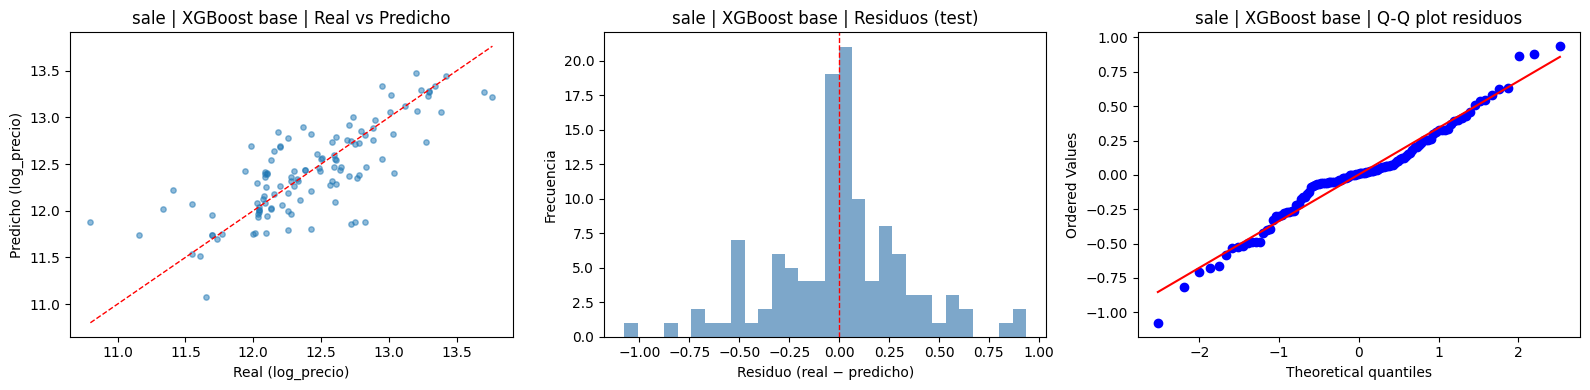

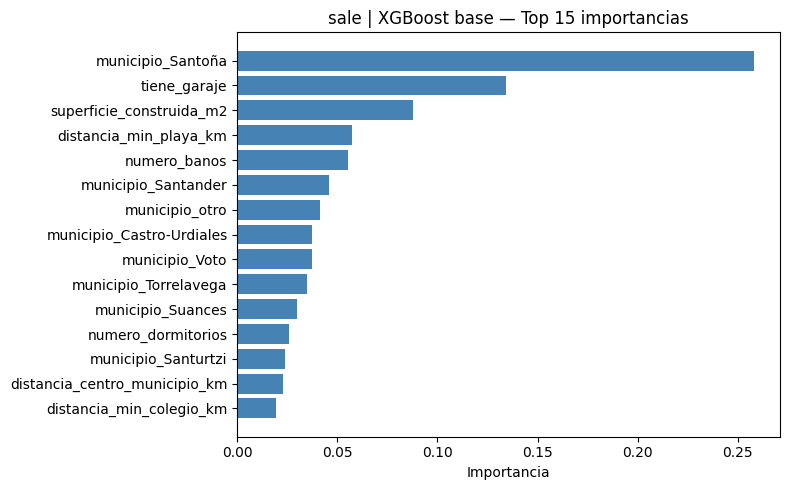


--- XGBoost | GridSearch (192 combinaciones, CV=5) ---
  Mejores params: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 200, 'reg_lambda': 5, 'subsample': 0.7}
  CV RMSE (mejor): 0.36396
split     MSE    RMSE     MAE      R2    MAPE
train 0.05526 0.23506 0.17334 0.83087 0.01414
   CV     NaN 0.36396     NaN     NaN     NaN
 test 0.09936 0.31522 0.23112 0.63506 0.01877
  Sobreajuste → ratio RMSE test/train: 1.3410 | delta R2: 0.1958


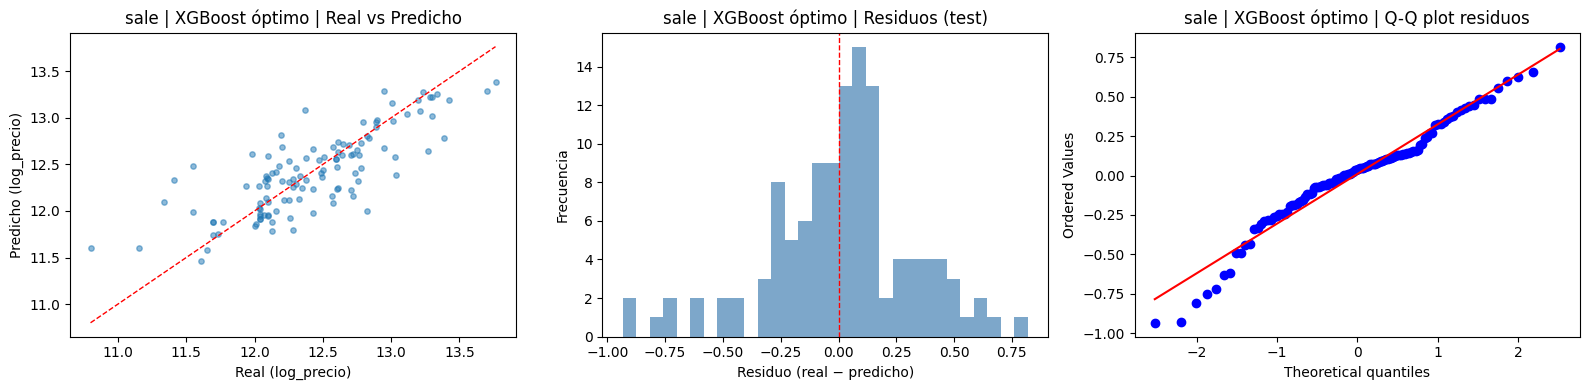

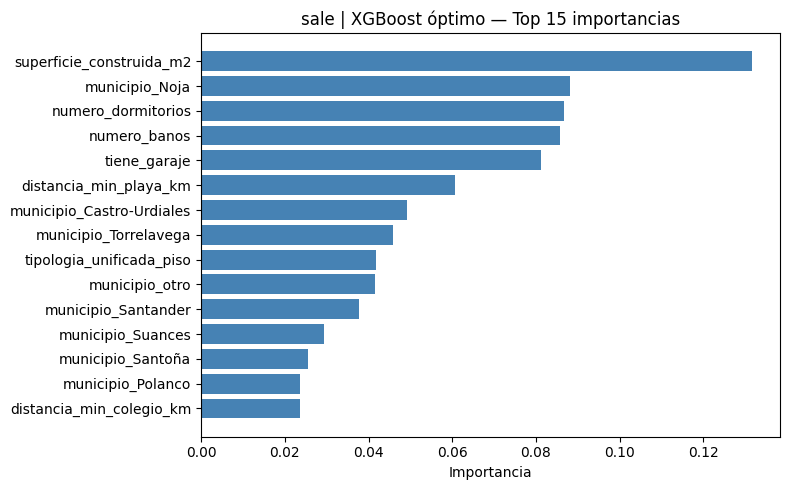


────────────────────────────────────────────────────────────
GRADIENT BOOSTING (sklearn)
────────────────────────────────────────────────────────────

--- GBR | Modelo base ---
split     MSE    RMSE     MAE      R2    MAPE
train 0.04299 0.20734 0.15802 0.86841 0.01287
 test 0.09885 0.31440 0.23482 0.63696 0.01904
  Sobreajuste → ratio RMSE test/train: 1.5163 | delta R2: 0.2315


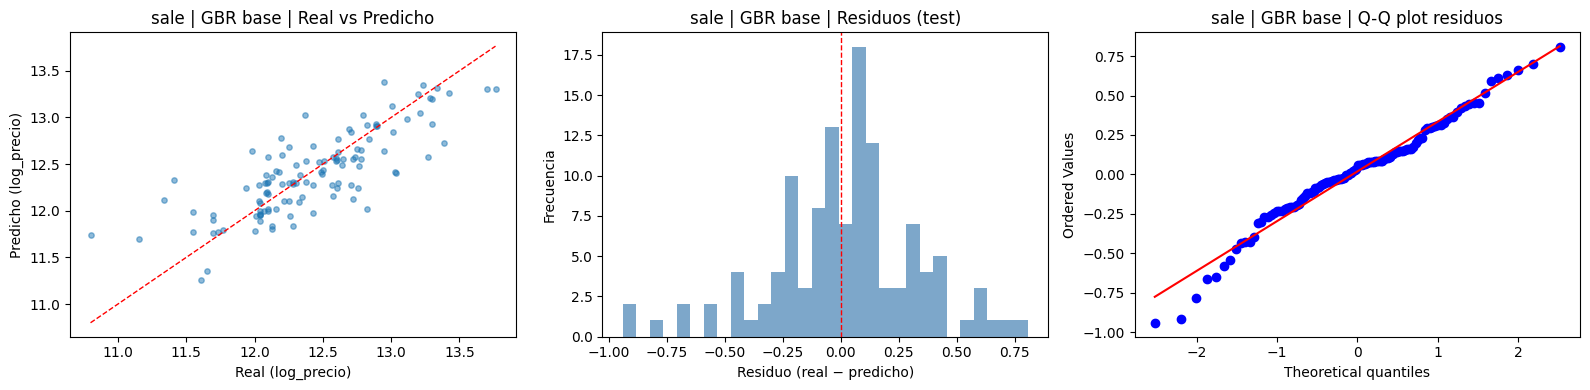

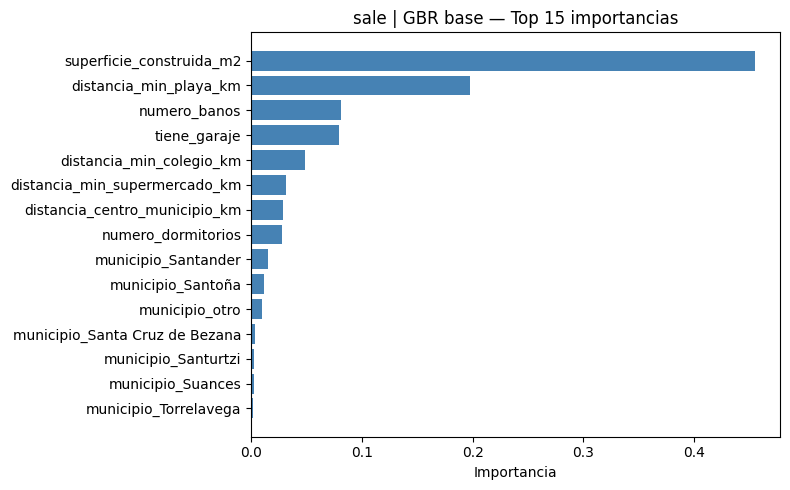


--- GBR | GridSearch (48 combinaciones, CV=5) ---
  Mejores params: {'learning_rate': 0.05, 'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 200, 'subsample': 0.9}
  CV RMSE (mejor): 0.37350
split     MSE    RMSE     MAE      R2    MAPE
train 0.01124 0.10600 0.07717 0.96561 0.00629
   CV     NaN 0.37350     NaN     NaN     NaN
 test 0.10184 0.31912 0.22423 0.62597 0.01827
  Sobreajuste → ratio RMSE test/train: 3.0106 | delta R2: 0.3396


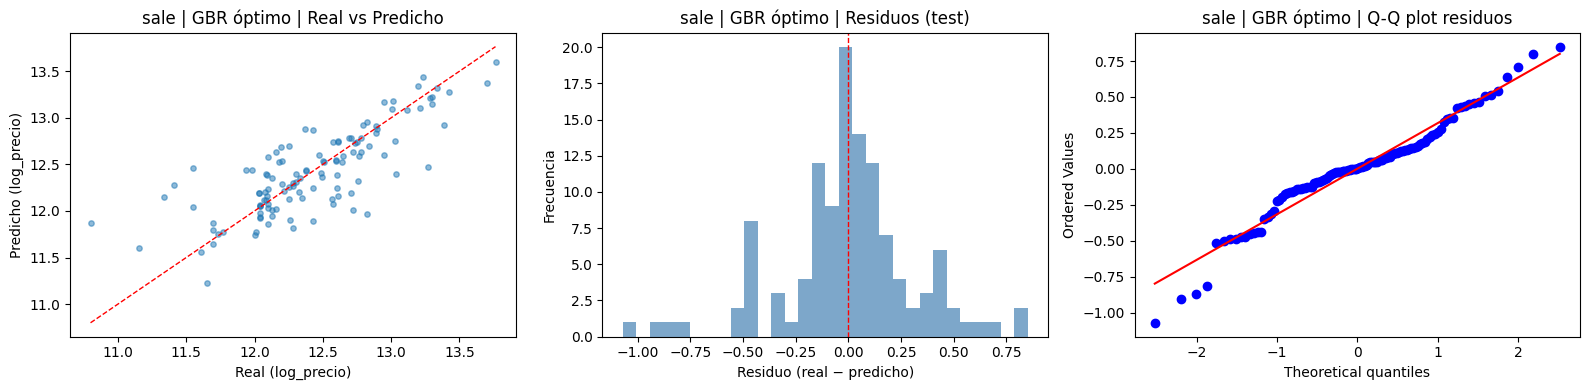

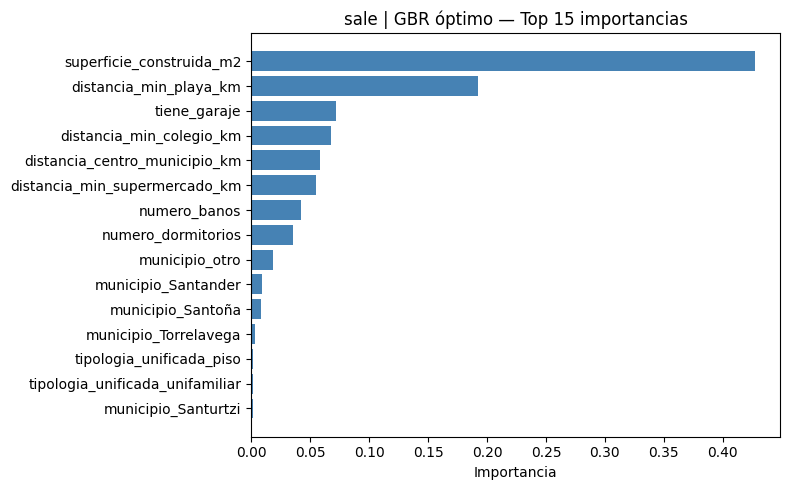


────────────────────────────────────────────────────────────
ADABOOST
────────────────────────────────────────────────────────────

--- AdaBoost | Modelo base ---
split     MSE    RMSE     MAE      R2    MAPE
train 0.10190 0.31922 0.26463 0.68808 0.02142
 test 0.13101 0.36195 0.28181 0.51884 0.02275
  Sobreajuste → ratio RMSE test/train: 1.1339 | delta R2: 0.1692


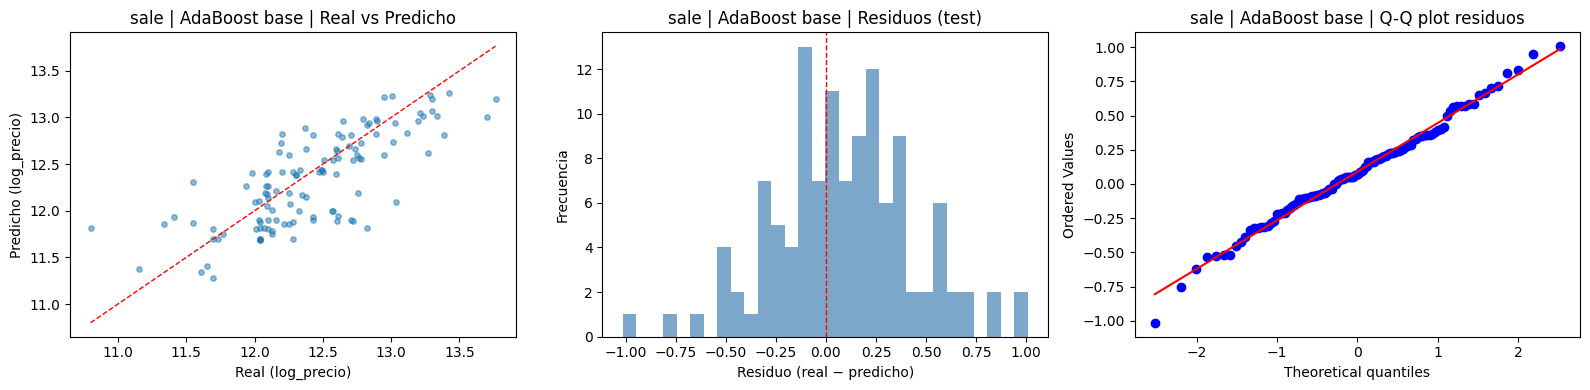

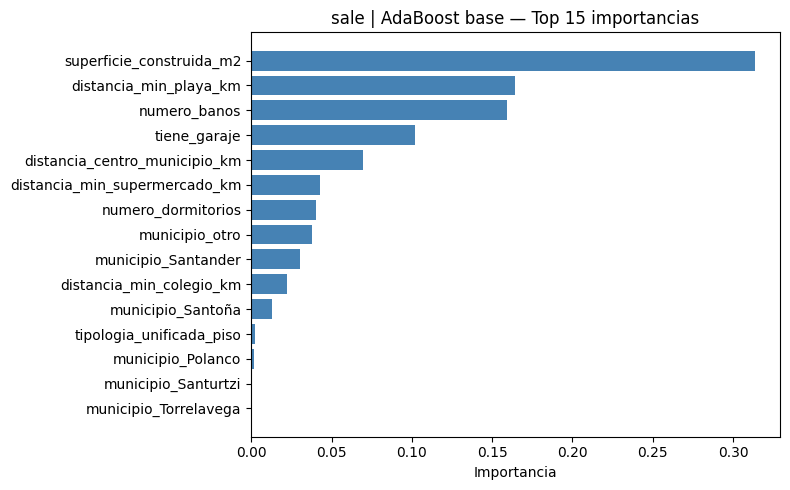


--- AdaBoost | GridSearch (27 combinaciones, CV=5) ---
  Mejores params: {'estimator__max_depth': 7, 'learning_rate': 1.5, 'n_estimators': 400}
  CV RMSE (mejor): 0.35606
split     MSE    RMSE     MAE      R2    MAPE
train 0.01165 0.10792 0.08396 0.96435 0.00677
   CV     NaN 0.35606     NaN     NaN     NaN
 test 0.09784 0.31280 0.23176 0.64065 0.01886
  Sobreajuste → ratio RMSE test/train: 2.8984 | delta R2: 0.3237


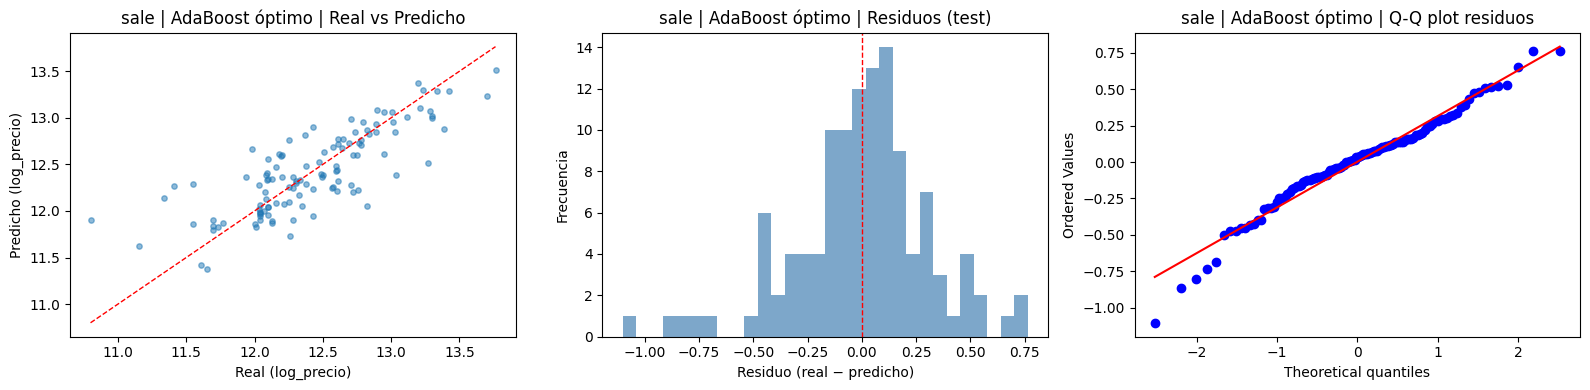

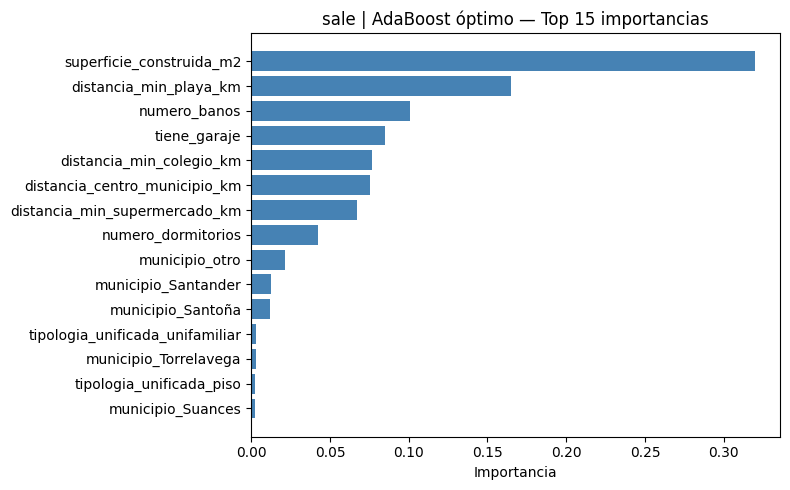


RESUMEN SALE — comparativa modelos
dataset   modelo   fase  train_RMSE  test_RMSE  train_R2  test_R2  cv_RMSE
   sale  XGBoost   base     0.00766    0.33854   0.99982  0.57907      NaN
   sale  XGBoost optimo     0.23506    0.31522   0.83087  0.63506  0.36396
   sale      GBR   base     0.20734    0.31440   0.86841  0.63696      NaN
   sale      GBR optimo     0.10600    0.31912   0.96561  0.62597  0.37350
   sale AdaBoost   base     0.31922    0.36195   0.68808  0.51884      NaN
   sale AdaBoost optimo     0.10792    0.31280   0.96435  0.64065  0.35606

DATASET: RENT
Filas cargadas: 477

Agrupando municipios con < 10 observaciones:
  Municipios con >= 10 obs: 9
  Municipios con <  10 obs (→ municipio_otro): 29
    ['municipio_Ampuero', 'municipio_Barcena de Cicero', 'municipio_Cartes', 'municipio_Colindres', 'municipio_Cudon', 'municipio_Entrambasaguas', 'municipio_Gallarta', 'municipio_Getxo', 'municipio_Guarnizo', 'municipio_Guriezo', 'municipio_Liendo', 'municipio_Limpias', 'munic

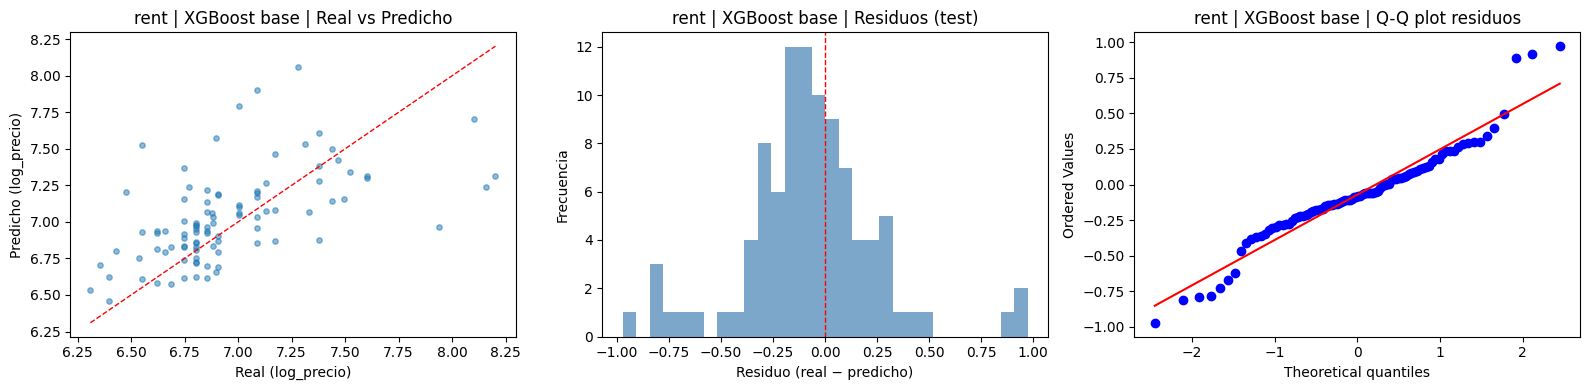

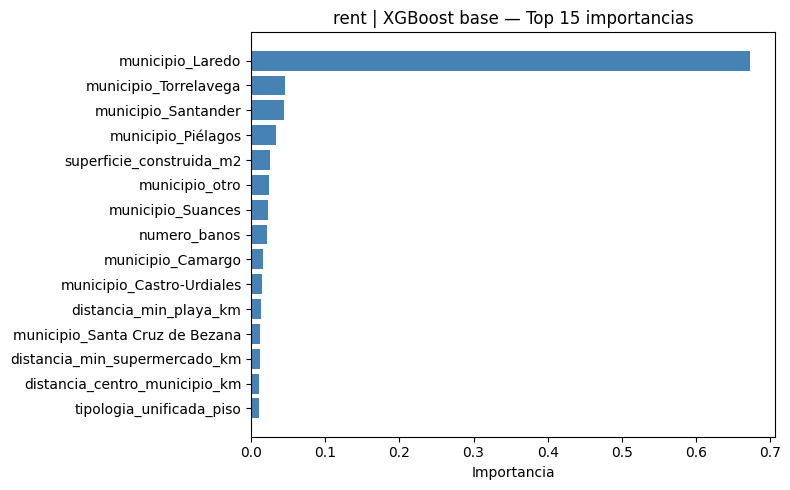


--- XGBoost | GridSearch (192 combinaciones, CV=5) ---
  Mejores params: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 200, 'reg_lambda': 5, 'subsample': 0.9}
  CV RMSE (mejor): 0.29769
split     MSE    RMSE     MAE      R2    MAPE
train 0.04246 0.20605 0.14276 0.73232 0.02013
   CV     NaN 0.29769     NaN     NaN     NaN
 test 0.08343 0.28883 0.20178 0.38804 0.02845
  Sobreajuste → ratio RMSE test/train: 1.4017 | delta R2: 0.3443


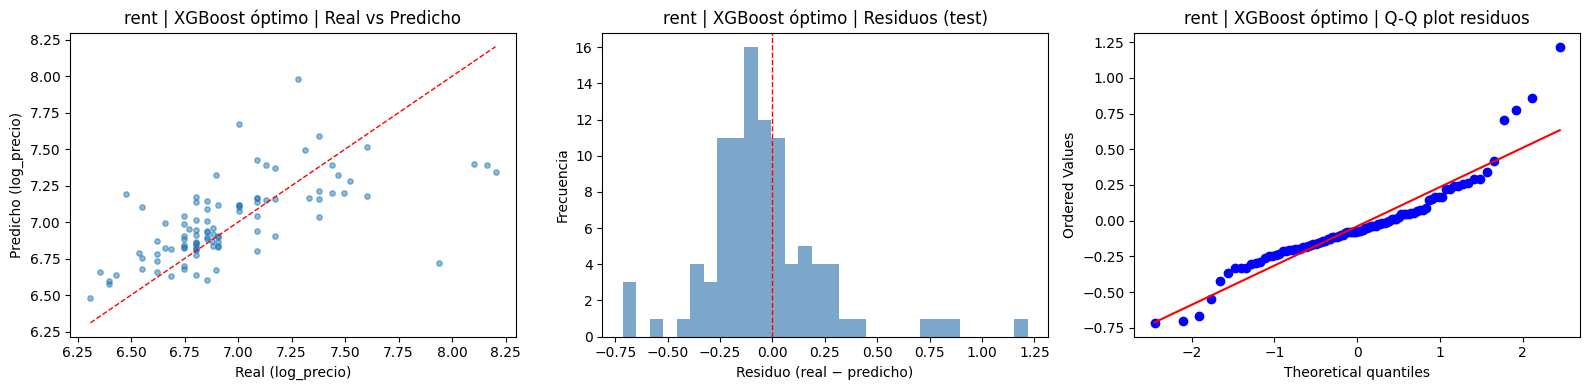

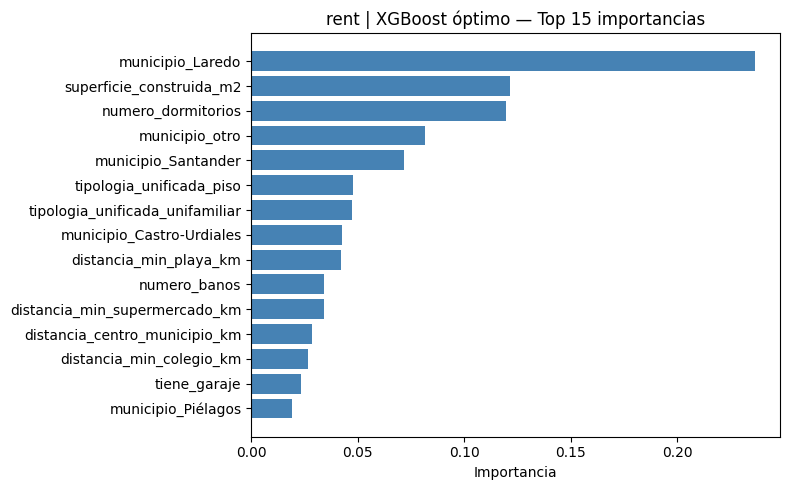


────────────────────────────────────────────────────────────
GRADIENT BOOSTING (sklearn)
────────────────────────────────────────────────────────────

--- GBR | Modelo base ---
split     MSE    RMSE     MAE      R2    MAPE
train 0.02840 0.16852 0.12040 0.82095 0.01704
 test 0.08497 0.29150 0.21043 0.37669 0.02978
  Sobreajuste → ratio RMSE test/train: 1.7298 | delta R2: 0.4443


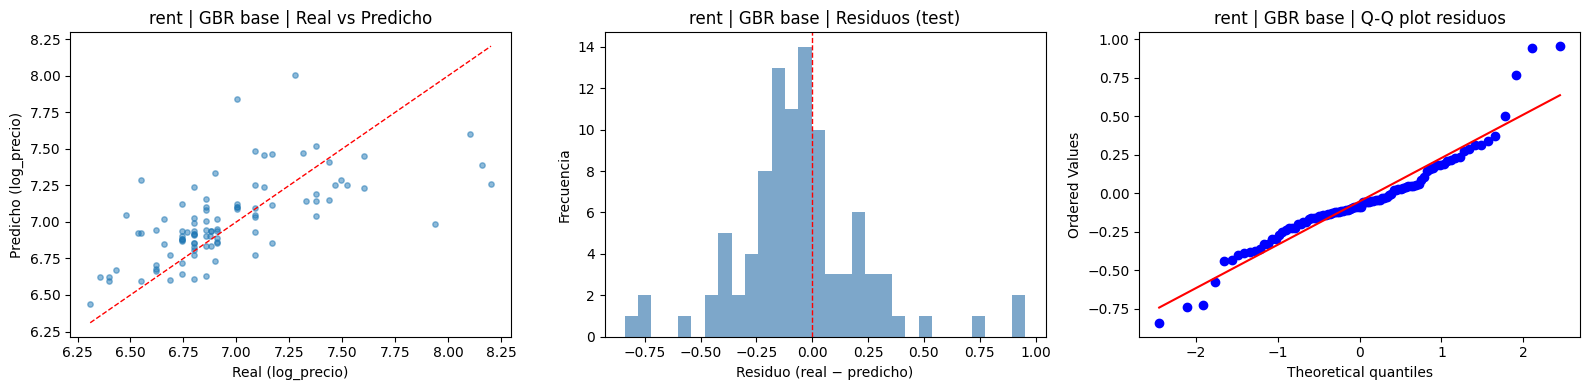

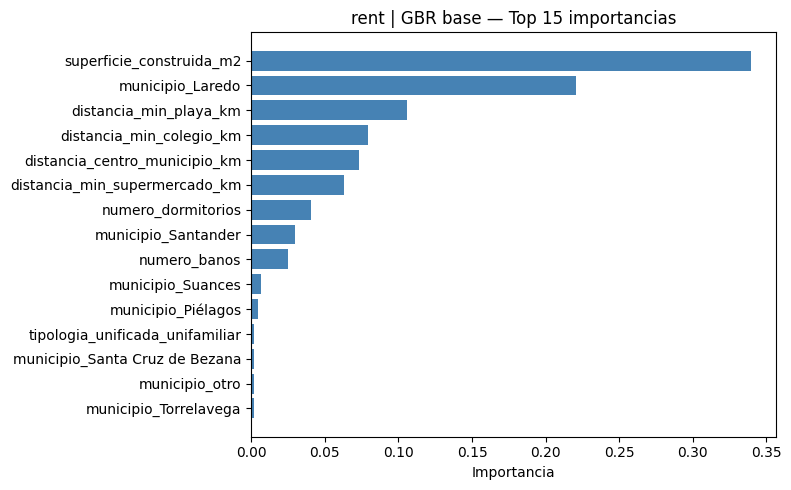


--- GBR | GridSearch (48 combinaciones, CV=5) ---
  Mejores params: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 10, 'n_estimators': 200, 'subsample': 0.9}
  CV RMSE (mejor): 0.29690
split     MSE    RMSE     MAE      R2    MAPE
train 0.03998 0.19994 0.13751 0.74795 0.01942
   CV     NaN 0.29690     NaN     NaN     NaN
 test 0.08756 0.29590 0.21130 0.35774 0.02986
  Sobreajuste → ratio RMSE test/train: 1.4799 | delta R2: 0.3902


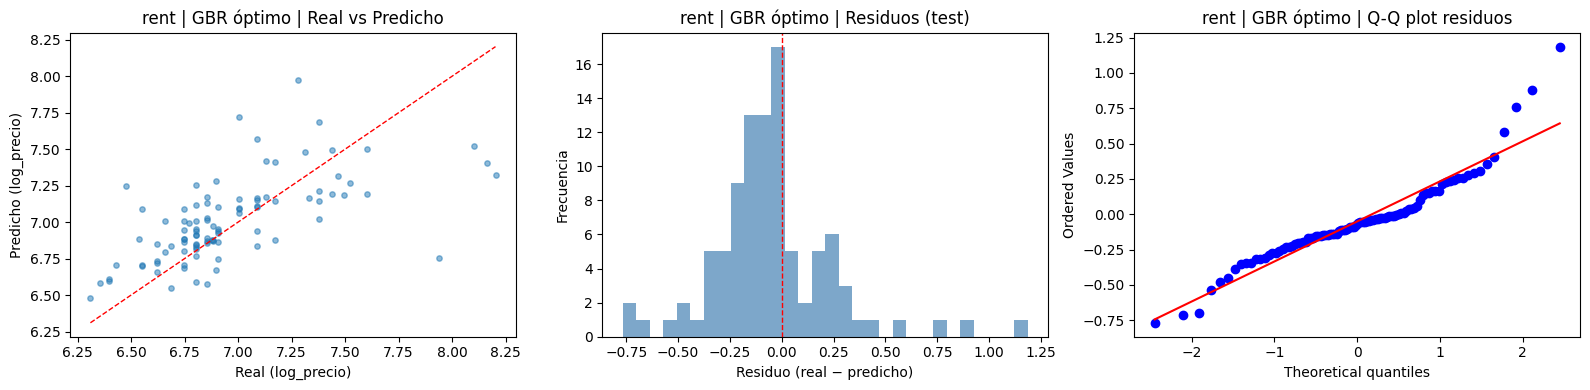

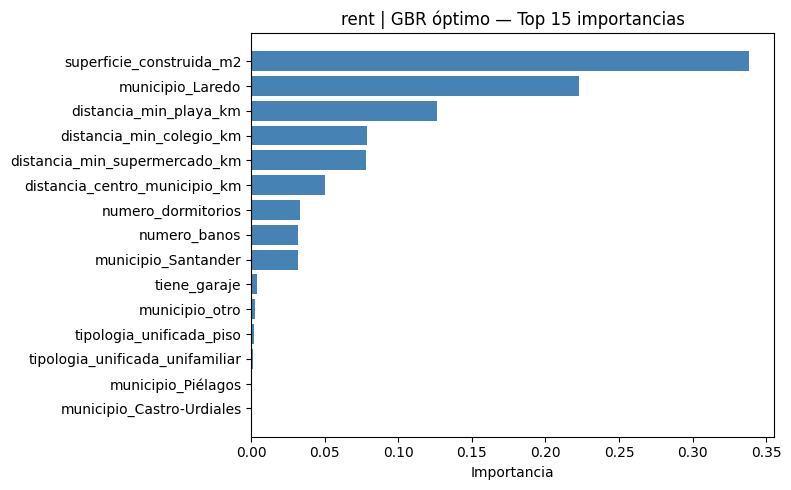


────────────────────────────────────────────────────────────
ADABOOST
────────────────────────────────────────────────────────────

--- AdaBoost | Modelo base ---
split     MSE    RMSE     MAE      R2    MAPE
train 0.09841 0.31370 0.26789 0.37951 0.03857
 test 0.11480 0.33883 0.29327 0.15787 0.04223
  Sobreajuste → ratio RMSE test/train: 1.0801 | delta R2: 0.2216


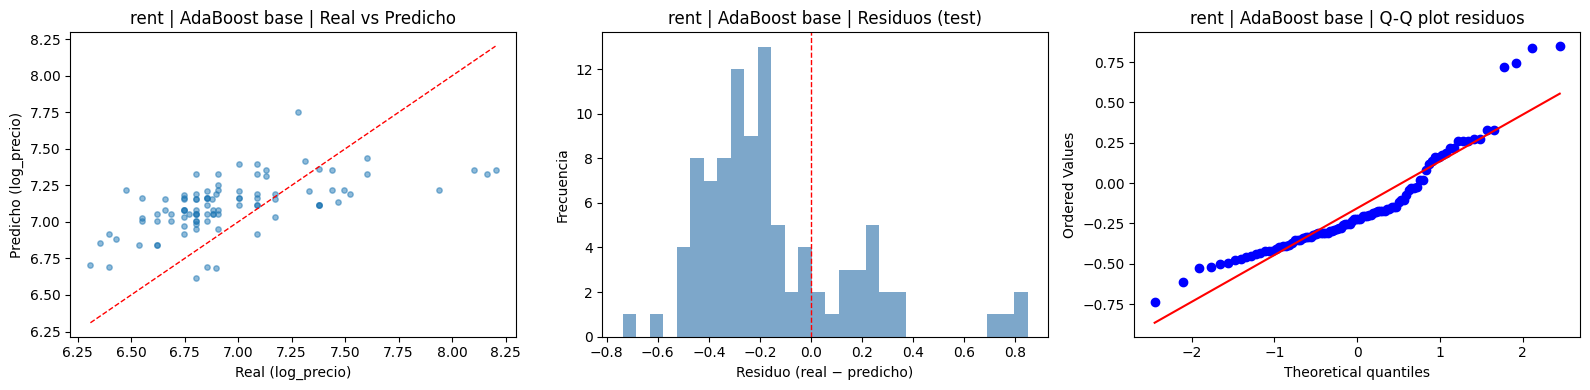

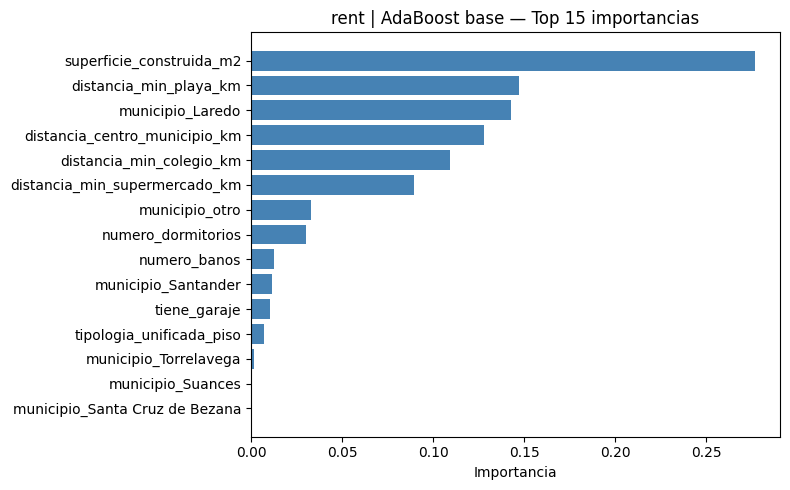


--- AdaBoost | GridSearch (27 combinaciones, CV=5) ---
  Mejores params: {'estimator__max_depth': 7, 'learning_rate': 1.5, 'n_estimators': 400}
  CV RMSE (mejor): 0.31359
split     MSE    RMSE     MAE      R2    MAPE
train 0.01344 0.11591 0.08985 0.91529 0.01295
   CV     NaN 0.31359     NaN     NaN     NaN
 test 0.08811 0.29683 0.19956 0.35367 0.02818
  Sobreajuste → ratio RMSE test/train: 2.5609 | delta R2: 0.5616


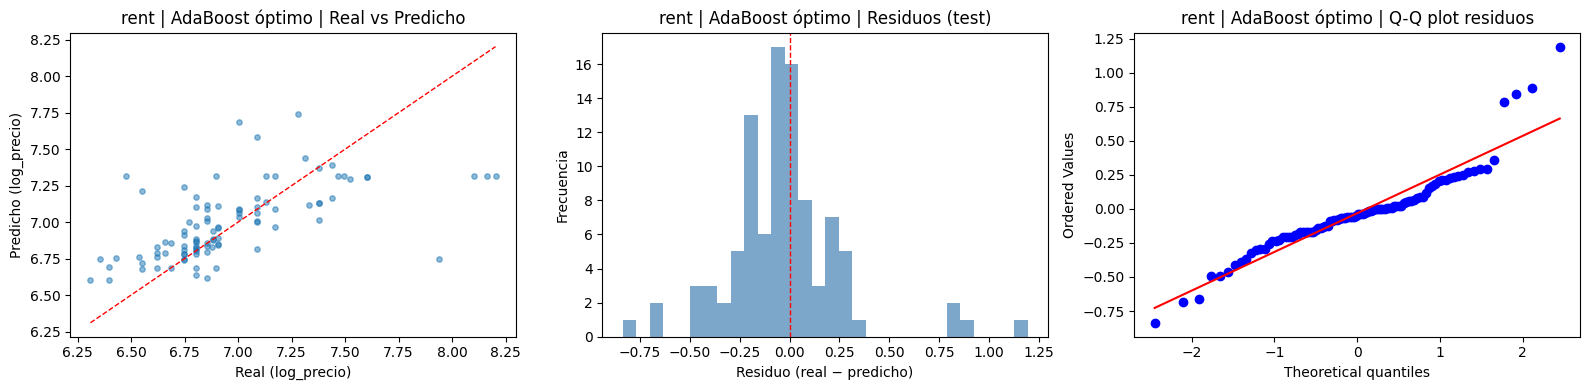

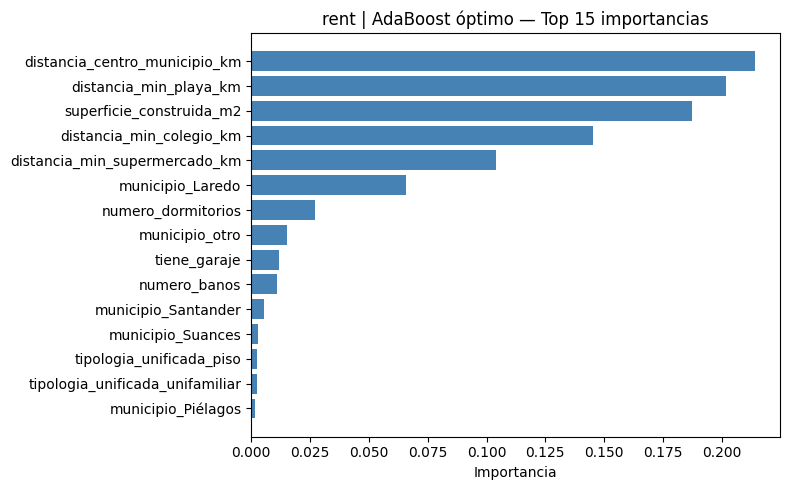


RESUMEN RENT — comparativa modelos
dataset   modelo   fase  train_RMSE  test_RMSE  train_R2  test_R2  cv_RMSE
   rent  XGBoost   base     0.02734    0.33088   0.99529  0.19691      NaN
   rent  XGBoost optimo     0.20605    0.28883   0.73232  0.38804  0.29769
   rent      GBR   base     0.16852    0.29150   0.82095  0.37669      NaN
   rent      GBR optimo     0.19994    0.29590   0.74795  0.35774  0.29690
   rent AdaBoost   base     0.31370    0.33883   0.37951  0.15787      NaN
   rent AdaBoost optimo     0.11591    0.29683   0.91529  0.35367  0.31359

RESUMEN GLOBAL
dataset   modelo   fase  train_RMSE  test_RMSE  train_R2  test_R2  cv_RMSE
   sale  XGBoost   base     0.00766    0.33854   0.99982  0.57907      NaN
   sale  XGBoost optimo     0.23506    0.31522   0.83087  0.63506  0.36396
   sale      GBR   base     0.20734    0.31440   0.86841  0.63696      NaN
   sale      GBR optimo     0.10600    0.31912   0.96561  0.62597  0.37350
   sale AdaBoost   base     0.31922    0.36195  

,dataset,modelo,fase,train_RMSE,test_RMSE,train_R2,test_R2,cv_RMSE
0,sale,XGBoost,base,0.00766,0.33854,0.99982,0.57907,NaN
1,sale,XGBoost,optimo,0.23506,0.31522,0.83087,0.63506,0.363962
2,sale,GBR,base,0.20734,0.31440,0.86841,0.63696,NaN
3,sale,GBR,optimo,0.10600,0.31912,0.96561,0.62597,0.373496
4,sale,AdaBoost,base,0.31922,0.36195,0.68808,0.51884,NaN
5,sale,AdaBoost,optimo,0.10792,0.31280,0.96435,0.64065,0.356063
6,rent,XGBoost,base,0.02734,0.33088,0.99529,0.19691,NaN
7,rent,XGBoost,optimo,0.20605,0.28883,0.73232,0.38804,0.297689
8,rent,GBR,base,0.16852,0.29150,0.82095,0.37669,NaN
9,rent,GBR,optimo,0.19994,0.29590,0.74795,0.35774,0.296901


In [4]:
# ── Bucle principal: un bloque por dataset ────────────────────────────────────

all_summary_rows = []

for dataset_name, dataset_path in DATASETS.items():
    print()
    print("=" * 100)
    print(f"DATASET: {dataset_name.upper()}")
    print("=" * 100)

    # ── Carga ─────────────────────────────────────────────────────────────────
    df = pd.read_csv(dataset_path)
    df = df[df[TARGET_COL].notna()].copy()
    print(f"Filas cargadas: {len(df)}")

    # ── Colapsar municipios raros ─────────────────────────────────────────────
    print(f"\nAgrupando municipios con < {MIN_OBS_MUNICIPIO} observaciones:")
    df, final_muni_cols = collapse_rare_municipios(df, MUNICIPIO_FEATURES, MIN_OBS_MUNICIPIO)

    # ── Preparar features ─────────────────────────────────────────────────────
    all_feature_cols = BASE_FEATURES + final_muni_cols
    X = prepare_X(df, all_feature_cols)
    y = df[TARGET_COL].reset_index(drop=True)

    # alinear índices tras reset del imputer
    y = df[TARGET_COL].values

    print(f"Features finales: {X.shape[1]} | Filas: {X.shape[0]}")

    # ── Split 80/20 ───────────────────────────────────────────────────────────
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )
    print(f"Train: {len(X_train)} | Test: {len(X_test)}")

    feature_names = X_train.columns.tolist()

    # ══════════════════════════════════════════════════════════════════════════
    # 1. XGBoost
    # ══════════════════════════════════════════════════════════════════════════
    print("\n" + "─" * 60)
    print("XGBOOST")
    print("─" * 60)

    # Base
    xgb_base = XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
    xgb_base, xgb_base_train, xgb_base_test = run_base_model(
        xgb_base, X_train, X_test, y_train, y_test, "XGBoost", dataset_name
    )
    plot_diagnostics(y_test, xgb_base.predict(X_test), f"{dataset_name} | XGBoost base")
    fi_xgb_base = plot_feature_importance(
        xgb_base.feature_importances_, feature_names,
        f"{dataset_name} | XGBoost base — Top 15 importancias"
    )

    # Grid Search
    xgb_opt, xgb_gs, xgb_opt_train, xgb_opt_test, xgb_cv_rmse = run_grid_search(
        XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
        PARAM_GRID_XGB, X_train, X_test, y_train, y_test, "XGBoost", dataset_name
    )
    plot_diagnostics(y_test, xgb_opt.predict(X_test), f"{dataset_name} | XGBoost óptimo")
    fi_xgb_opt = plot_feature_importance(
        xgb_opt.feature_importances_, feature_names,
        f"{dataset_name} | XGBoost óptimo — Top 15 importancias"
    )

    # ══════════════════════════════════════════════════════════════════════════
    # 2. GradientBoosting
    # ══════════════════════════════════════════════════════════════════════════
    print("\n" + "─" * 60)
    print("GRADIENT BOOSTING (sklearn)")
    print("─" * 60)

    # Base
    gbr_base = GradientBoostingRegressor(random_state=RANDOM_STATE)
    gbr_base, gbr_base_train, gbr_base_test = run_base_model(
        gbr_base, X_train, X_test, y_train, y_test, "GBR", dataset_name
    )
    plot_diagnostics(y_test, gbr_base.predict(X_test), f"{dataset_name} | GBR base")
    fi_gbr_base = plot_feature_importance(
        gbr_base.feature_importances_, feature_names,
        f"{dataset_name} | GBR base — Top 15 importancias"
    )

    # Grid Search
    gbr_opt, gbr_gs, gbr_opt_train, gbr_opt_test, gbr_cv_rmse = run_grid_search(
        GradientBoostingRegressor(random_state=RANDOM_STATE),
        PARAM_GRID_GBR, X_train, X_test, y_train, y_test, "GBR", dataset_name
    )
    plot_diagnostics(y_test, gbr_opt.predict(X_test), f"{dataset_name} | GBR óptimo")
    fi_gbr_opt = plot_feature_importance(
        gbr_opt.feature_importances_, feature_names,
        f"{dataset_name} | GBR óptimo — Top 15 importancias"
    )

    # ══════════════════════════════════════════════════════════════════════════
    # 3. AdaBoost
    # ══════════════════════════════════════════════════════════════════════════
    print("\n" + "─" * 60)
    print("ADABOOST")
    print("─" * 60)

    # Base
    ada_base = AdaBoostRegressor(
        estimator=DecisionTreeRegressor(max_depth=3),
        random_state=RANDOM_STATE,
    )
    ada_base, ada_base_train, ada_base_test = run_base_model(
        ada_base, X_train, X_test, y_train, y_test, "AdaBoost", dataset_name
    )
    plot_diagnostics(y_test, ada_base.predict(X_test), f"{dataset_name} | AdaBoost base")
    fi_ada_base = plot_feature_importance(
        ada_base.feature_importances_, feature_names,
        f"{dataset_name} | AdaBoost base — Top 15 importancias"
    )

    # Grid Search
    ada_opt, ada_gs, ada_opt_train, ada_opt_test, ada_cv_rmse = run_grid_search(
        AdaBoostRegressor(estimator=DecisionTreeRegressor(), random_state=RANDOM_STATE),
        PARAM_GRID_ADA, X_train, X_test, y_train, y_test, "AdaBoost", dataset_name
    )
    plot_diagnostics(y_test, ada_opt.predict(X_test), f"{dataset_name} | AdaBoost óptimo")
    fi_ada_opt = plot_feature_importance(
        ada_opt.feature_importances_, feature_names,
        f"{dataset_name} | AdaBoost óptimo — Top 15 importancias"
    )

    # ══════════════════════════════════════════════════════════════════════════
    # Resumen del dataset
    # ══════════════════════════════════════════════════════════════════════════
    print("\n" + "=" * 60)
    print(f"RESUMEN {dataset_name.upper()} — comparativa modelos")
    print("=" * 60)

    rows = [
        {"dataset": dataset_name, "modelo": "XGBoost",  "fase": "base",
         "train_RMSE": float(xgb_base_train["RMSE"].iloc[0]), "test_RMSE": float(xgb_base_test["RMSE"].iloc[0]),
         "train_R2":   float(xgb_base_train["R2"].iloc[0]),   "test_R2":   float(xgb_base_test["R2"].iloc[0]),   "cv_RMSE": None},
        {"dataset": dataset_name, "modelo": "XGBoost",  "fase": "optimo",
         "train_RMSE": float(xgb_opt_train["RMSE"].iloc[0]),  "test_RMSE": float(xgb_opt_test["RMSE"].iloc[0]),
         "train_R2":   float(xgb_opt_train["R2"].iloc[0]),    "test_R2":   float(xgb_opt_test["R2"].iloc[0]),    "cv_RMSE": xgb_cv_rmse},
        {"dataset": dataset_name, "modelo": "GBR",      "fase": "base",
         "train_RMSE": float(gbr_base_train["RMSE"].iloc[0]), "test_RMSE": float(gbr_base_test["RMSE"].iloc[0]),
         "train_R2":   float(gbr_base_train["R2"].iloc[0]),   "test_R2":   float(gbr_base_test["R2"].iloc[0]),   "cv_RMSE": None},
        {"dataset": dataset_name, "modelo": "GBR",      "fase": "optimo",
         "train_RMSE": float(gbr_opt_train["RMSE"].iloc[0]),  "test_RMSE": float(gbr_opt_test["RMSE"].iloc[0]),
         "train_R2":   float(gbr_opt_train["R2"].iloc[0]),    "test_R2":   float(gbr_opt_test["R2"].iloc[0]),    "cv_RMSE": gbr_cv_rmse},
        {"dataset": dataset_name, "modelo": "AdaBoost", "fase": "base",
         "train_RMSE": float(ada_base_train["RMSE"].iloc[0]), "test_RMSE": float(ada_base_test["RMSE"].iloc[0]),
         "train_R2":   float(ada_base_train["R2"].iloc[0]),   "test_R2":   float(ada_base_test["R2"].iloc[0]),   "cv_RMSE": None},
        {"dataset": dataset_name, "modelo": "AdaBoost", "fase": "optimo",
         "train_RMSE": float(ada_opt_train["RMSE"].iloc[0]),  "test_RMSE": float(ada_opt_test["RMSE"].iloc[0]),
         "train_R2":   float(ada_opt_train["R2"].iloc[0]),    "test_R2":   float(ada_opt_test["R2"].iloc[0]),    "cv_RMSE": ada_cv_rmse},
    ]
    all_summary_rows.extend(rows)

    ds_summary = pd.DataFrame(rows)
    print(ds_summary.round(5).to_string(index=False))

print()
print("=" * 100)
print("RESUMEN GLOBAL")
print("=" * 100)
global_summary = pd.DataFrame(all_summary_rows)
print(global_summary.round(5).to_string(index=False))
global_summary

---

## Regularización Lineal: Lasso y Ridge

Modelos lineales regularizados sobre los mismos datasets y features que los modelos de boosting.

- **Pipeline** con `StandardScaler` (necesario para que la regularización sea equitativa entre features)
- Modelo base con `alpha=1.0` y luego `GridSearchCV` barriendo diferentes alphas
- Diagnósticos (Real vs Predicho, Residuos, Q-Q) y coeficientes top-15 por valor absoluto
- Resumen comparativo final: boosting + regularización

In [5]:
# ── Imports adicionales para regularización ───────────────────────────────────
from sklearn.linear_model import Lasso, Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# ── Grids de búsqueda para Lasso y Ridge ─────────────────────────────────────
PARAM_GRID_LASSO = {
    "model__alpha": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
}

PARAM_GRID_RIDGE = {
    "model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
}

print("Imports y grids de regularización cargados.")


Imports y grids de regularización cargados.


In [6]:
# ── Función auxiliar: coeficientes lineales ───────────────────────────────────

def plot_coefficients(coef: "np.ndarray", feature_names: list, title: str, top_n: int = 15):
    """Muestra los top_n coeficientes ordenados por valor absoluto."""
    fi = (
        pd.DataFrame({"feature": feature_names, "coef": coef})
        .assign(abs_coef=lambda d: d["coef"].abs())
        .sort_values("abs_coef", ascending=False)
        .head(top_n)
    )
    colors = ["steelblue" if c >= 0 else "tomato" for c in fi["coef"]]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(fi["feature"][::-1], fi["coef"][::-1], color=colors[::-1])
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel("Coeficiente (escala estandarizada)")
    plt.tight_layout()
    plt.show()
    return fi


print("Función plot_coefficients cargada.")


Función plot_coefficients cargada.



DATASET: SALE — Lasso & Ridge
Filas cargadas: 588

Agrupando municipios con < 10 observaciones:
  Municipios no presentes en el dataset: ['municipio_Sobremazas', 'municipio_Villaescusa', 'municipio_Viveda']
  Municipios con >= 10 obs: 13
  Municipios con <  10 obs (→ municipio_otro): 22
    ['municipio_Ampuero', 'municipio_Barcena de Cicero', 'municipio_Cartes', 'municipio_Colindres', 'municipio_Cudon', 'municipio_El Astillero', 'municipio_Entrambasaguas', 'municipio_Gallarta', 'municipio_Getxo', 'municipio_Guarnizo', 'municipio_Guriezo', 'municipio_Liendo', 'municipio_Limpias', 'municipio_Marina de Cudeyo', 'municipio_Miengo', 'municipio_Ramales de la Victoria', 'municipio_Reocin', 'municipio_Ribamontan al Mar', 'municipio_Santa Maria de Cayon', 'municipio_Santillana del Mar', 'municipio_Solares', 'municipio_Villapresente']
Features finales: 25 | Filas: 588
Train: 470 | Test: 118

────────────────────────────────────────────────────────────
LASSO
─────────────────────────────────────

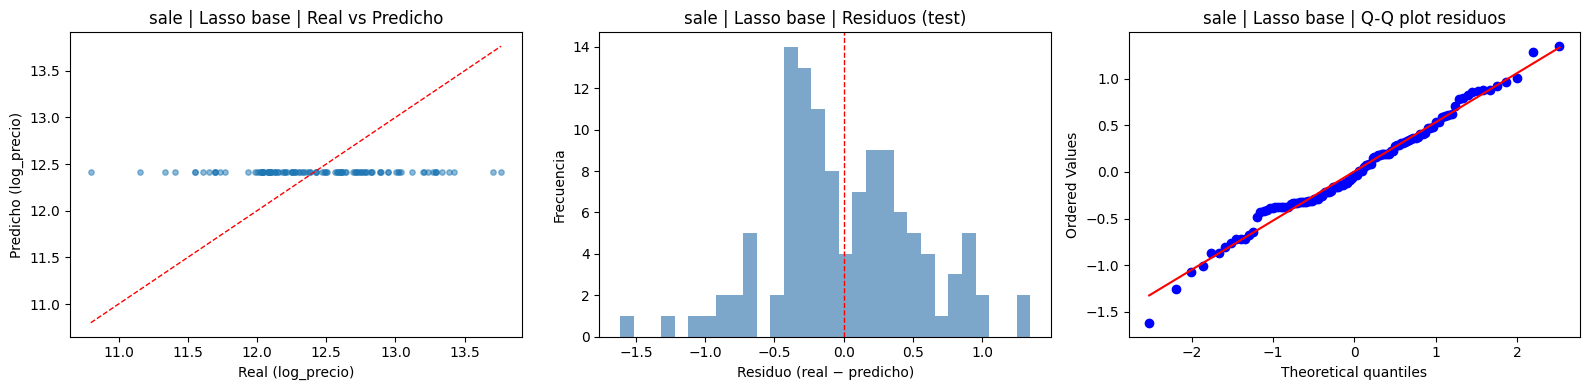

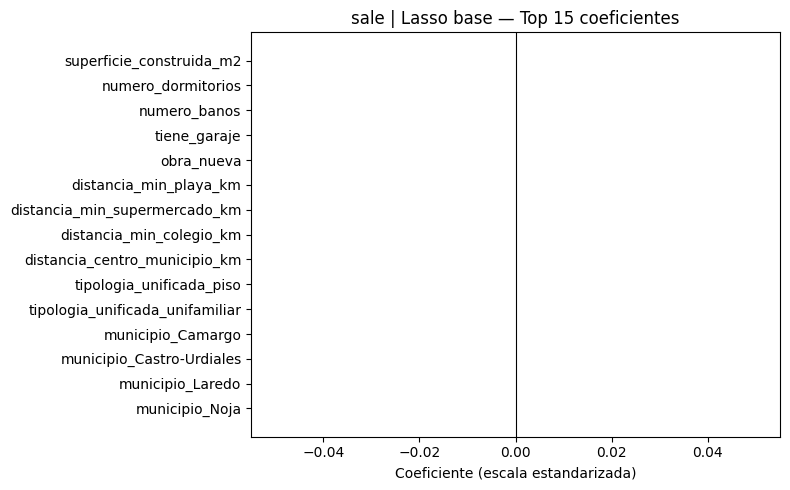


--- Lasso | GridSearch (6 combinaciones, CV=5) ---
  Mejores params: {'model__alpha': 0.01}
  CV RMSE (mejor): 0.39377
split     MSE    RMSE     MAE      R2    MAPE
train 0.13675 0.36980 0.26648 0.58140 0.02166
   CV     NaN 0.39377     NaN     NaN     NaN
 test 0.13865 0.37236 0.27731 0.49077 0.02241
  Sobreajuste → ratio RMSE test/train: 1.0069 | delta R2: 0.0906


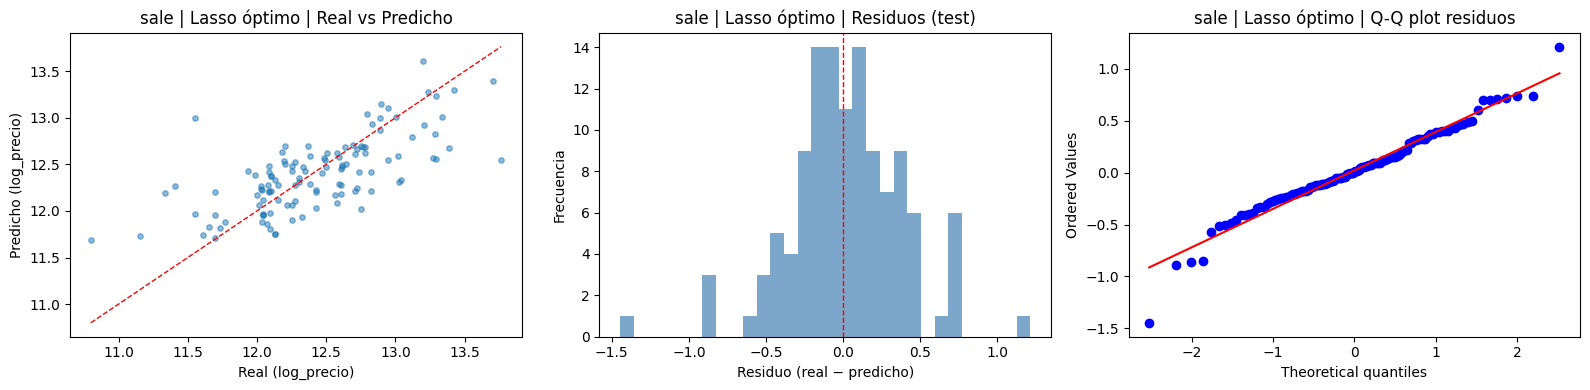

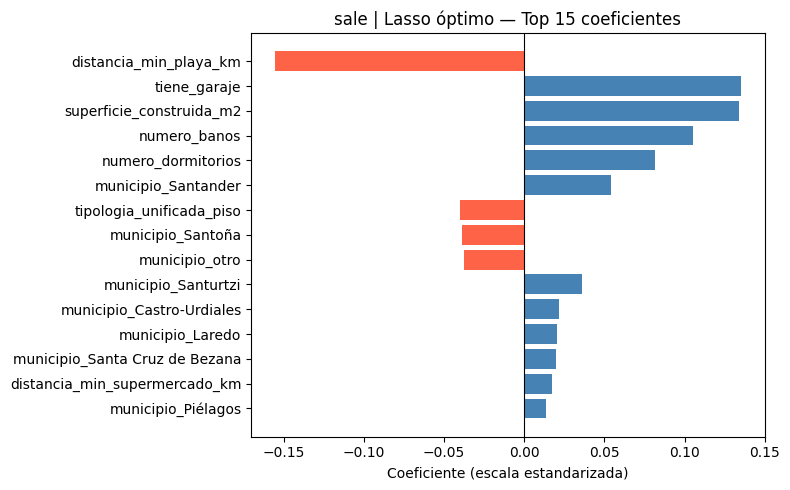


────────────────────────────────────────────────────────────
RIDGE
────────────────────────────────────────────────────────────

--- Ridge | Modelo base ---
split     MSE    RMSE     MAE      R2    MAPE
train 0.13408 0.36616 0.26620 0.58960 0.02163
 test 0.14076 0.37518 0.28064 0.48303 0.02267
  Sobreajuste → ratio RMSE test/train: 1.0246 | delta R2: 0.1066


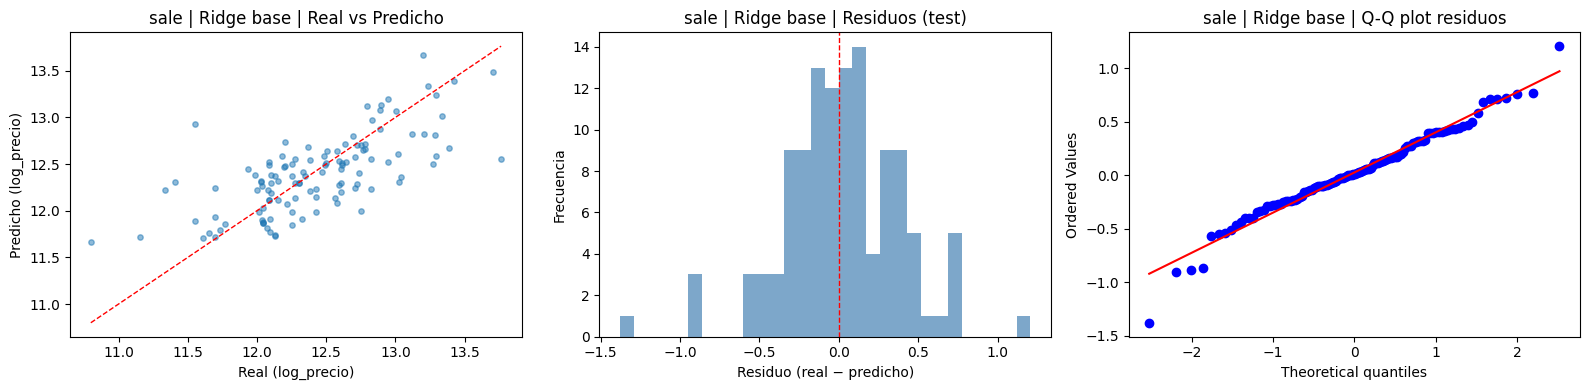

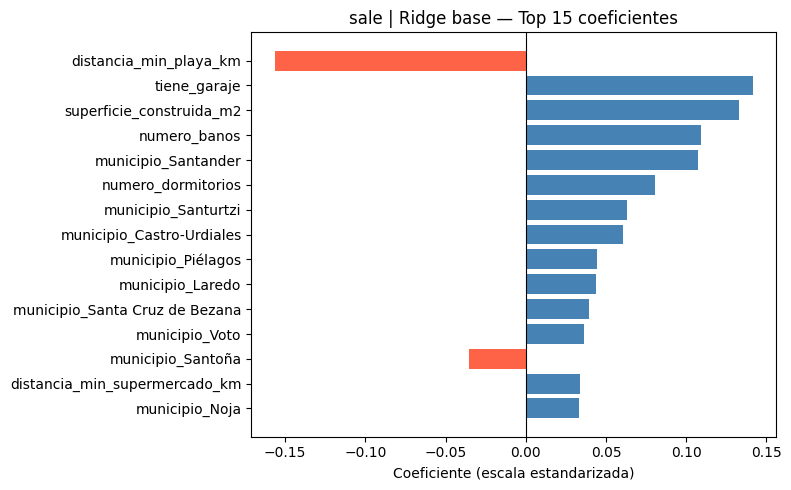


--- Ridge | GridSearch (6 combinaciones, CV=5) ---
  Mejores params: {'model__alpha': 100.0}
  CV RMSE (mejor): 0.39021
split     MSE    RMSE     MAE      R2    MAPE
train 0.13736 0.37062 0.26395 0.57956 0.02146
   CV     NaN 0.39021     NaN     NaN     NaN
 test 0.13811 0.37164 0.27179 0.49274 0.02197
  Sobreajuste → ratio RMSE test/train: 1.0028 | delta R2: 0.0868


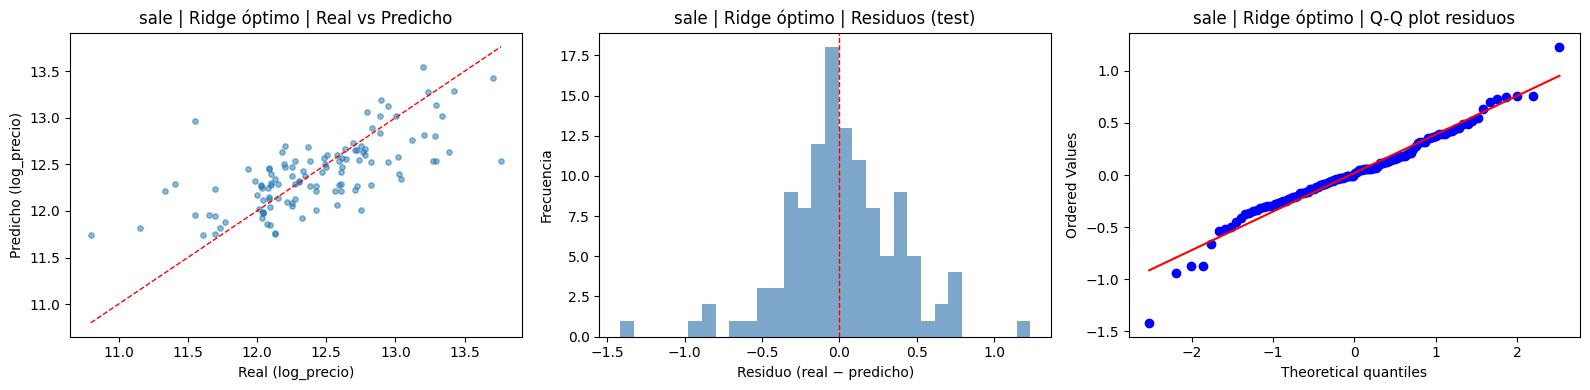

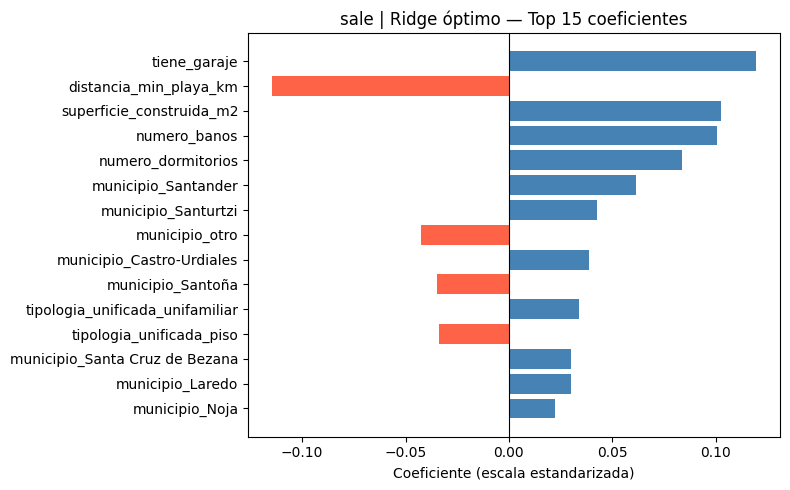


RESUMEN SALE — Lasso & Ridge
dataset modelo   fase  train_RMSE  test_RMSE  train_R2  test_R2  cv_RMSE
   sale  Lasso   base     0.57157    0.52183   0.00000 -0.00012      NaN
   sale  Lasso optimo     0.36980    0.37236   0.58140  0.49077  0.39377
   sale  Ridge   base     0.36616    0.37518   0.58960  0.48303      NaN
   sale  Ridge optimo     0.37062    0.37164   0.57956  0.49274  0.39021

DATASET: RENT — Lasso & Ridge
Filas cargadas: 477

Agrupando municipios con < 10 observaciones:
  Municipios con >= 10 obs: 9
  Municipios con <  10 obs (→ municipio_otro): 29
    ['municipio_Ampuero', 'municipio_Barcena de Cicero', 'municipio_Cartes', 'municipio_Colindres', 'municipio_Cudon', 'municipio_Entrambasaguas', 'municipio_Gallarta', 'municipio_Getxo', 'municipio_Guarnizo', 'municipio_Guriezo', 'municipio_Liendo', 'municipio_Limpias', 'municipio_Marina de Cudeyo', 'municipio_Miengo', 'municipio_Noja', 'municipio_Polanco', 'municipio_Ramales de la Victoria', 'municipio_Reocin', 'municipio_

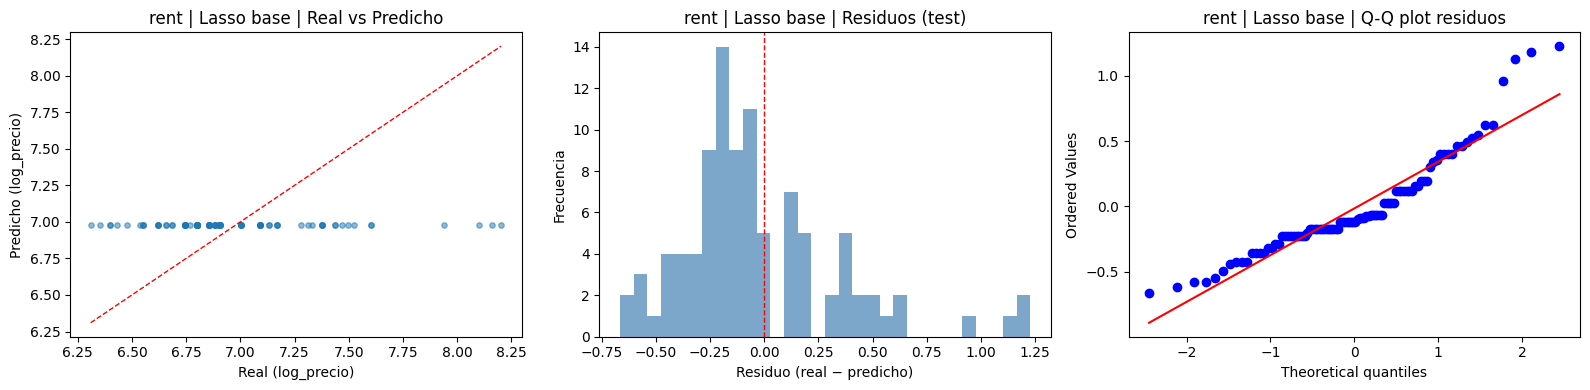

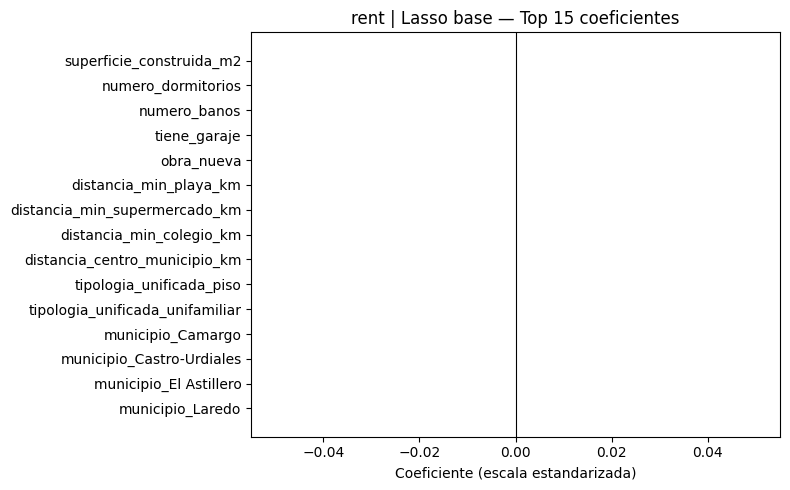


--- Lasso | GridSearch (6 combinaciones, CV=5) ---
  Mejores params: {'model__alpha': 0.01}
  CV RMSE (mejor): 0.29230
split     MSE    RMSE     MAE      R2    MAPE
train 0.08124 0.28503 0.20015 0.48777 0.02819
   CV     NaN 0.29230     NaN     NaN     NaN
 test 0.08101 0.28463 0.19560 0.40572 0.02752
  Sobreajuste → ratio RMSE test/train: 0.9986 | delta R2: 0.0820


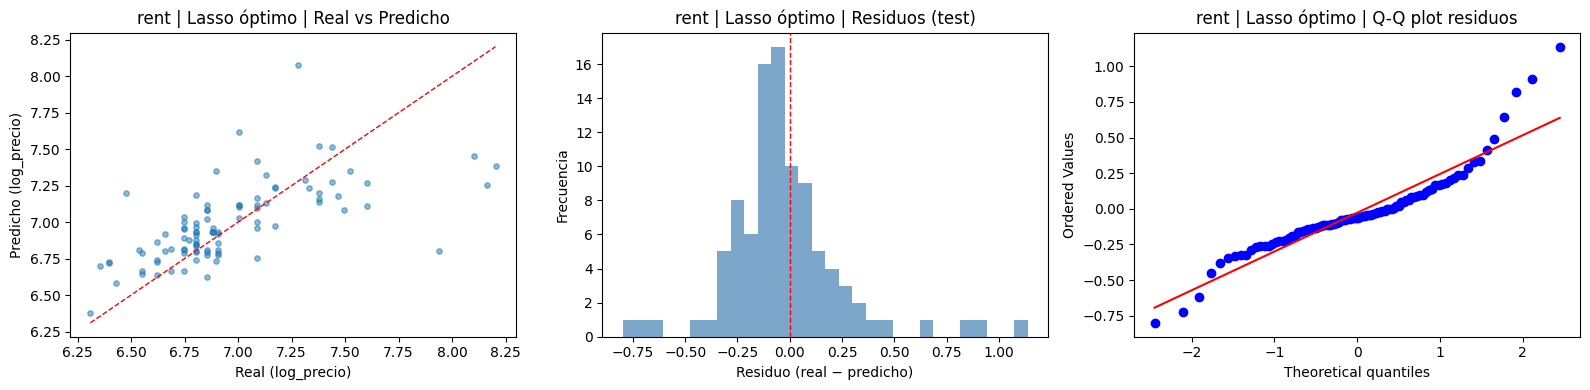

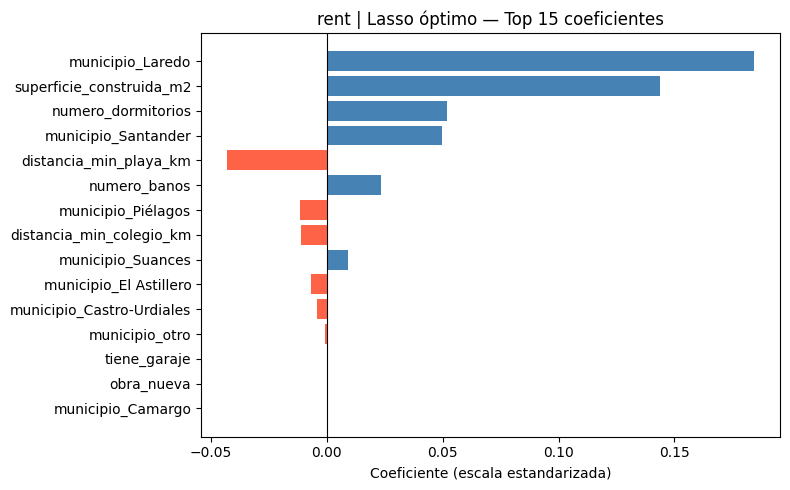


────────────────────────────────────────────────────────────
RIDGE
────────────────────────────────────────────────────────────

--- Ridge | Modelo base ---
split     MSE    RMSE     MAE      R2    MAPE
train 0.07947 0.28191 0.19601 0.49893 0.02764
 test 0.08253 0.28728 0.20234 0.39461 0.02851
  Sobreajuste → ratio RMSE test/train: 1.0190 | delta R2: 0.1043


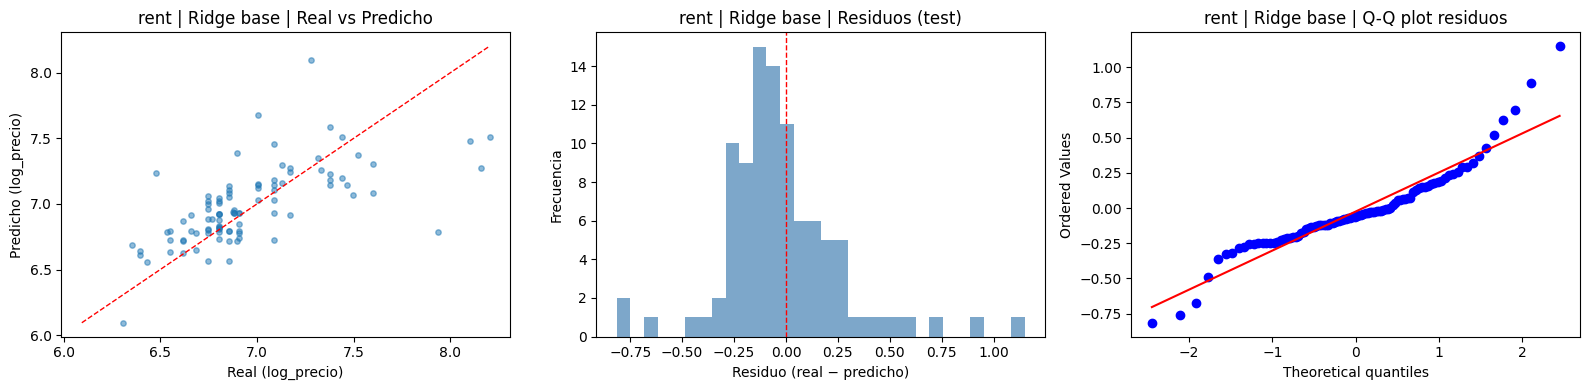

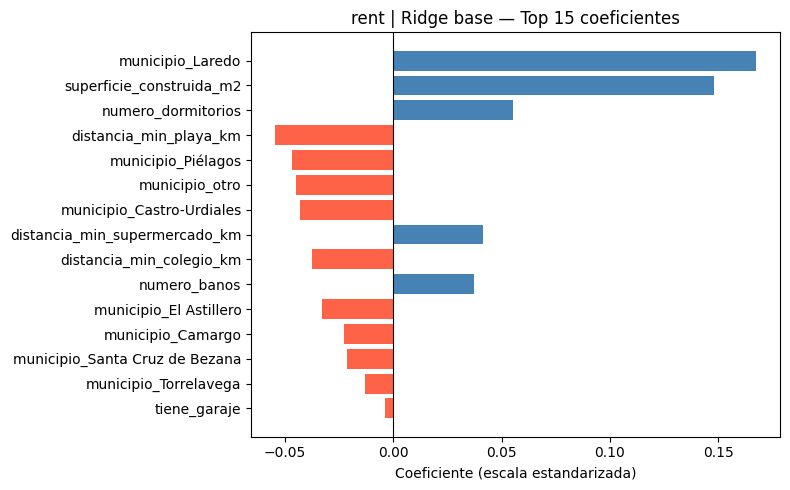


--- Ridge | GridSearch (6 combinaciones, CV=5) ---
  Mejores params: {'model__alpha': 10.0}
  CV RMSE (mejor): 0.29263
split     MSE    RMSE     MAE      R2    MAPE
train 0.07954 0.28202 0.19660 0.49851 0.02771
   CV     NaN 0.29263     NaN     NaN     NaN
 test 0.08189 0.28616 0.20113 0.39930 0.02833
  Sobreajuste → ratio RMSE test/train: 1.0147 | delta R2: 0.0992


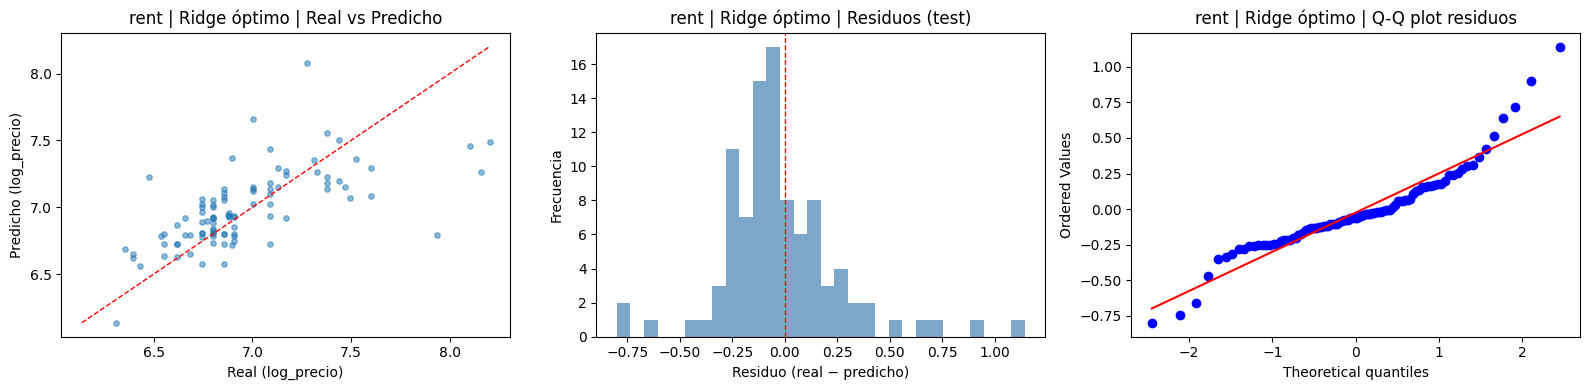

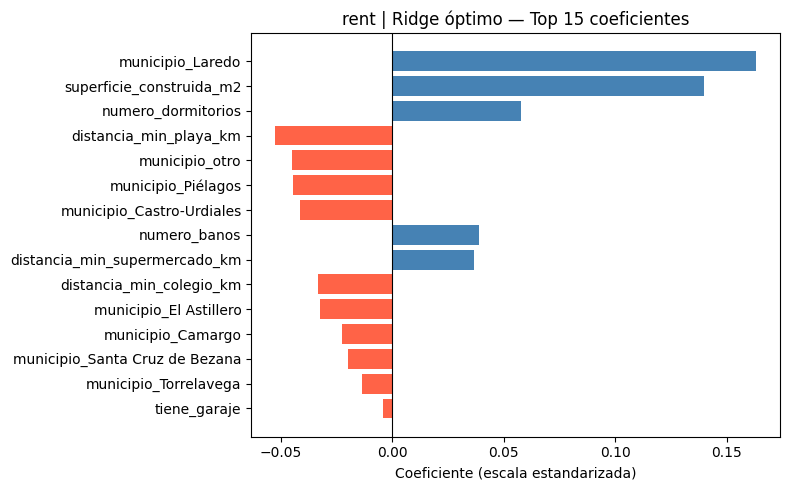


RESUMEN RENT — Lasso & Ridge
dataset modelo   fase  train_RMSE  test_RMSE  train_R2  test_R2  cv_RMSE
   rent  Lasso   base     0.39825    0.36959   0.00000 -0.00201      NaN
   rent  Lasso optimo     0.28503    0.28463   0.48777  0.40572  0.29230
   rent  Ridge   base     0.28191    0.28728   0.49893  0.39461      NaN
   rent  Ridge optimo     0.28202    0.28616   0.49851  0.39930  0.29263

RESUMEN GLOBAL — Boosting + Regularización
dataset   modelo   fase  train_RMSE  test_RMSE  train_R2  test_R2  cv_RMSE
   sale  XGBoost   base     0.00766    0.33854   0.99982  0.57907      NaN
   sale  XGBoost optimo     0.23506    0.31522   0.83087  0.63506  0.36396
   sale      GBR   base     0.20734    0.31440   0.86841  0.63696      NaN
   sale      GBR optimo     0.10600    0.31912   0.96561  0.62597  0.37350
   sale AdaBoost   base     0.31922    0.36195   0.68808  0.51884      NaN
   sale AdaBoost optimo     0.10792    0.31280   0.96435  0.64065  0.35606
   rent  XGBoost   base     0.02734 

,dataset,modelo,fase,train_RMSE,test_RMSE,train_R2,test_R2,cv_RMSE
0,sale,XGBoost,base,0.00766,0.33854,0.99982,0.57907,NaN
1,sale,XGBoost,optimo,0.23506,0.31522,0.83087,0.63506,0.363962
2,sale,GBR,base,0.20734,0.31440,0.86841,0.63696,NaN
3,sale,GBR,optimo,0.10600,0.31912,0.96561,0.62597,0.373496
4,sale,AdaBoost,base,0.31922,0.36195,0.68808,0.51884,NaN
5,sale,AdaBoost,optimo,0.10792,0.31280,0.96435,0.64065,0.356063
6,rent,XGBoost,base,0.02734,0.33088,0.99529,0.19691,NaN
7,rent,XGBoost,optimo,0.20605,0.28883,0.73232,0.38804,0.297689
8,rent,GBR,base,0.16852,0.29150,0.82095,0.37669,NaN
9,rent,GBR,optimo,0.19994,0.29590,0.74795,0.35774,0.296901


In [7]:
# ── Bucle Lasso y Ridge: un bloque por dataset ────────────────────────────────

reg_summary_rows = []

for dataset_name, dataset_path in DATASETS.items():
    print()
    print("=" * 100)
    print(f"DATASET: {dataset_name.upper()} — Lasso & Ridge")
    print("=" * 100)

    # ── Carga ─────────────────────────────────────────────────────────────────
    df = pd.read_csv(dataset_path)
    df = df[df[TARGET_COL].notna()].copy()
    print(f"Filas cargadas: {len(df)}")

    # ── Colapsar municipios raros ─────────────────────────────────────────────
    print(f"\nAgrupando municipios con < {MIN_OBS_MUNICIPIO} observaciones:")
    df, final_muni_cols = collapse_rare_municipios(df, MUNICIPIO_FEATURES, MIN_OBS_MUNICIPIO)

    # ── Preparar features ─────────────────────────────────────────────────────
    all_feature_cols = BASE_FEATURES + final_muni_cols
    X = prepare_X(df, all_feature_cols)
    y = df[TARGET_COL].values

    print(f"Features finales: {X.shape[1]} | Filas: {X.shape[0]}")

    # ── Split 80/20 (misma semilla → mismos datos que boosting) ───────────────
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )
    print(f"Train: {len(X_train)} | Test: {len(X_test)}")

    feature_names = X_train.columns.tolist()

    # ══════════════════════════════════════════════════════════════════════════
    # 1. Lasso
    # ══════════════════════════════════════════════════════════════════════════
    print("\n" + "─" * 60)
    print("LASSO")
    print("─" * 60)

    lasso_pipe = Pipeline([("scaler", StandardScaler()), ("model", Lasso(alpha=1.0, max_iter=10000))])

    # Base
    lasso_base, lasso_base_train, lasso_base_test = run_base_model(
        lasso_pipe, X_train, X_test, y_train, y_test, "Lasso", dataset_name
    )
    plot_diagnostics(y_test, lasso_base.predict(X_test), f"{dataset_name} | Lasso base")
    plot_coefficients(
        lasso_base.named_steps["model"].coef_, feature_names,
        f"{dataset_name} | Lasso base — Top 15 coeficientes"
    )

    # Grid Search
    lasso_opt, lasso_gs, lasso_opt_train, lasso_opt_test, lasso_cv_rmse = run_grid_search(
        Pipeline([("scaler", StandardScaler()), ("model", Lasso(max_iter=10000))]),
        PARAM_GRID_LASSO, X_train, X_test, y_train, y_test, "Lasso", dataset_name
    )
    plot_diagnostics(y_test, lasso_opt.predict(X_test), f"{dataset_name} | Lasso óptimo")
    plot_coefficients(
        lasso_opt.named_steps["model"].coef_, feature_names,
        f"{dataset_name} | Lasso óptimo — Top 15 coeficientes"
    )

    # ══════════════════════════════════════════════════════════════════════════
    # 2. Ridge
    # ══════════════════════════════════════════════════════════════════════════
    print("\n" + "─" * 60)
    print("RIDGE")
    print("─" * 60)

    ridge_pipe = Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=1.0))])

    # Base
    ridge_base, ridge_base_train, ridge_base_test = run_base_model(
        ridge_pipe, X_train, X_test, y_train, y_test, "Ridge", dataset_name
    )
    plot_diagnostics(y_test, ridge_base.predict(X_test), f"{dataset_name} | Ridge base")
    plot_coefficients(
        ridge_base.named_steps["model"].coef_, feature_names,
        f"{dataset_name} | Ridge base — Top 15 coeficientes"
    )

    # Grid Search
    ridge_opt, ridge_gs, ridge_opt_train, ridge_opt_test, ridge_cv_rmse = run_grid_search(
        Pipeline([("scaler", StandardScaler()), ("model", Ridge())]),
        PARAM_GRID_RIDGE, X_train, X_test, y_train, y_test, "Ridge", dataset_name
    )
    plot_diagnostics(y_test, ridge_opt.predict(X_test), f"{dataset_name} | Ridge óptimo")
    plot_coefficients(
        ridge_opt.named_steps["model"].coef_, feature_names,
        f"{dataset_name} | Ridge óptimo — Top 15 coeficientes"
    )

    # ══════════════════════════════════════════════════════════════════════════
    # Resumen del dataset (Lasso + Ridge)
    # ══════════════════════════════════════════════════════════════════════════
    print("\n" + "=" * 60)
    print(f"RESUMEN {dataset_name.upper()} — Lasso & Ridge")
    print("=" * 60)

    rows = [
        {"dataset": dataset_name, "modelo": "Lasso",  "fase": "base",
         "train_RMSE": float(lasso_base_train["RMSE"].iloc[0]),  "test_RMSE": float(lasso_base_test["RMSE"].iloc[0]),
         "train_R2":   float(lasso_base_train["R2"].iloc[0]),    "test_R2":   float(lasso_base_test["R2"].iloc[0]),   "cv_RMSE": None},
        {"dataset": dataset_name, "modelo": "Lasso",  "fase": "optimo",
         "train_RMSE": float(lasso_opt_train["RMSE"].iloc[0]),   "test_RMSE": float(lasso_opt_test["RMSE"].iloc[0]),
         "train_R2":   float(lasso_opt_train["R2"].iloc[0]),     "test_R2":   float(lasso_opt_test["R2"].iloc[0]),    "cv_RMSE": lasso_cv_rmse},
        {"dataset": dataset_name, "modelo": "Ridge",  "fase": "base",
         "train_RMSE": float(ridge_base_train["RMSE"].iloc[0]),  "test_RMSE": float(ridge_base_test["RMSE"].iloc[0]),
         "train_R2":   float(ridge_base_train["R2"].iloc[0]),    "test_R2":   float(ridge_base_test["R2"].iloc[0]),   "cv_RMSE": None},
        {"dataset": dataset_name, "modelo": "Ridge",  "fase": "optimo",
         "train_RMSE": float(ridge_opt_train["RMSE"].iloc[0]),   "test_RMSE": float(ridge_opt_test["RMSE"].iloc[0]),
         "train_R2":   float(ridge_opt_train["R2"].iloc[0]),     "test_R2":   float(ridge_opt_test["R2"].iloc[0]),    "cv_RMSE": ridge_cv_rmse},
    ]
    reg_summary_rows.extend(rows)

    ds_reg_summary = pd.DataFrame(rows)
    print(ds_reg_summary.round(5).to_string(index=False))

print()
print("=" * 100)
print("RESUMEN GLOBAL — Boosting + Regularización")
print("=" * 100)
all_models_summary = pd.DataFrame(all_summary_rows + reg_summary_rows)
print(all_models_summary.round(5).to_string(index=False))
all_models_summary
